# 03 · Forecasting tomorrow's Lithuanian day-ahead prices

**Research question 3:** How accurately can tomorrow's 24 hourly Lithuanian prices be forecast with information
available before the day-ahead auction, and how much of the remaining error comes from forecasts of wind, solar
and load?

| Hypothesis | Statement |
|---|---|
| H8 | A model that uses only information available before the auction forecasts tomorrow's hourly prices significantly more accurately than a naive benchmark (lower MAE in January–August 2026, Diebold–Mariano test p < 0.05). |
| H9 | Replacing Lithuania's wind forecast with the wind output that actually occurred makes the price forecast significantly more accurate, so wind forecast errors are an important source of price forecast errors. |

*H9 was re-specified during the analysis.* The first design used ERA5 reanalysis wind as "perfect" information,
but ERA5 turned out to be a noisier measure of wind output than the grid operators' own forecasts (section 6
keeps that comparison). The test therefore uses the actual output, which is exactly what the forecast tries to
predict.

**The rule behind everything.** The auction for delivery day D closes at 12:00 CET on day D−1. A feature may be
used only if a trader would have known it then:

| Feature | Known at 12:00 CET on D−1? | Used as |
|---|---|---|
| Lithuanian prices of D−1, D−2, D−7 | yes, set in earlier auctions | full daily price curves |
| Neighbours' prices (EE, FI, SE4, PL) of D−1 | yes | same hour and daily mean |
| Load forecasts for D (LT, Baltic, Nordic, PL, DE) | yes, published at least 2 h before the auction | same hour and daily mean |
| Wind and solar forecasts for D (same regions) | see limitation below | same hour and daily mean |
| Residual load forecast (load − wind − solar) | as above | same hour and daily mean (LightGBM) |
| TTF gas price | only the close of D−2 | daily value |
| Nordic hydro deviation | published a few working days after the week | the week that started ≥ 11 days before D |
| Calendar, Lithuanian holidays, the Estlink 2 outage | yes | daily values |

Days follow the auction's clock (CET), so a delivery day runs from 01:00 to 01:00 Lithuanian time. The repeated
hour of the 25-hour day in October is averaged and the missing hour of the 23-hour day in March is interpolated
for the features; interpolated hours are never scored.

**Models.** A naive benchmark; Lasso with one model per hour (the LEAR approach), averaged over three training
windows and re-trained every day; LightGBM, tuned on the validation period and re-trained every week; and the
**pre-registered main model: the simple average of Lasso and LightGBM**. Prices are transformed with a scaled asinh
before training, which damps spikes and handles negative prices.

**Evaluation.** Training data run to September 2025. October–December 2025 is the validation period, used only to
choose LightGBM's settings. January–August 2026 is the test period: forecast once, day by day, with models trained
only on data before each forecast day.

**Improved model (sections 9–12).** After the test results were reviewed, an improved version (v2) was built.
All its choices are made on the validation period; because January–August 2026 has been seen, v2's results there
are only indicative. September 2026, which no decision used, is the clean test of v2 against the pre-registered
model. Heavy results are stored in `data/processed/q3_cache`, so a second run takes minutes; delete that folder to
recompute everything.

In [1]:
import time
import warnings
from pathlib import Path

import duckdb
import holidays
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import lasso_path
from threadpoolctl import threadpool_limits

# Lasso may warn that it stopped just short of full convergence on nearly identical features (e.g. Lithuanian and
# Estonian prices); the effect on the forecast is negligible. LightGBM warns about a renamed argument.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*eval_set.*")

FAST = False  # True: monthly re-training and fewer settings, for a quick test run of a few minutes
SEED = 42
TRAIN_END = pd.Timestamp("2025-09-30")
VALID = (pd.Timestamp("2025-10-01"), pd.Timestamp("2025-12-31"))
TEST = (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-08-31"))
LASSO_WINDOWS = [364] if FAST else [182, 364, 728]  # days of history for each Lasso model
LASSO_EVERY = "M" if FAST else "D"                  # how often Lasso is re-trained ("W" if it runs too slowly)
LGB_EVERY = "M" if FAST else "W"                    # how often LightGBM is re-trained
CLIP_SD = 5                                         # Lasso inputs are capped at ±5 standard deviations

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

CACHE = ROOT / "data" / "processed" / "q3_cache"   # stored forecasts; delete the folder to recompute everything
CACHE.mkdir(parents=True, exist_ok=True)


def cached(name, compute):
    # Load a stored result if there is one; otherwise compute it and store it.
    path = CACHE / f"{name}{'_fast' if FAST else ''}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    result = compute()
    pd.to_pickle(result, path)
    return result


con = duckdb.connect(str(ROOT / "data" / "lt_power.duckdb"), read_only=True)
tables = set(con.sql("SELECT table_name FROM information_schema.tables").df()["table_name"])
source = "lt_hourly_all" if "lt_hourly_all" in tables else "lt_hourly"   # all hours, incl. September 2026
lt = con.sql(f"""
    SELECT ts_utc, ts_local, price, price_ee, price_fi, price_se4, price_pl,
           load_mw, wind_mw, solar_mw, load_forecast_mw, wind_forecast_mw, solar_forecast_mw,
           wind_cf_lt, wind_cf_lv, wind_cf_ee, wind_cf_fi, wind_cf_se, wind_cf_pl, wind_cf_de
    FROM {source} ORDER BY ts_utc
""").df()
eua = (con.sql("SELECT trade_date, eua_proxy FROM eua_daily ORDER BY trade_date").df()
       if "eua_daily" in tables else pd.DataFrame(columns=["trade_date", "eua_proxy"]))
ntc = (con.sql("SELECT ts_utc, border, mw FROM ntc_hourly_border ORDER BY ts_utc").df()
       if "ntc_hourly_border" in tables else pd.DataFrame(columns=["ts_utc", "border", "mw"]))
zones = con.sql("SELECT * FROM forecast_hourly_zone WHERE zone <> 'LT' ORDER BY ts_utc").df()
gas = con.sql("SELECT trade_date, ttf_eur_mwh FROM gas_daily ORDER BY trade_date").df()
hydro = con.sql("""
    SELECT week_start, deviation_gwh FROM hydro_weekly
    WHERE area = 'NORDIC' AND is_complete ORDER BY week_start
""").df()
con.close()
print(f"{len(lt):,} hours up to {lt['ts_local'].max()}; neighbours' forecasts for {zones['zone'].nunique()} zones; "
      f"carbon proxy: {len(eua)} days; cross-border capacities: {ntc['border'].nunique()} borders")

32,759 hours up to 2026-09-26 23:00:00; neighbours' forecasts for 7 zones; carbon proxy: 957 days; cross-border capacities: 10 borders


In [2]:
def fmt_p(p):
    # p-value as text. A p-value is never exactly 0, so very small values are shown as an upper bound.
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def show_p(table):
    # Results table for display, with p-values below 0.001 written as <0.001.
    return table.assign(p_value=table["p_value"].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"))

## 1. How good are the forecasts that go into the model?

Forecast errors of the Lithuanian load, wind and solar forecasts, in MW and as a share of the actual average.
The load forecast became clearly worse in the latest year. If its errors cluster around midday, small solar and
batteries behind the meter are a likely cause: they change measured load in ways the forecast does not capture.

MAE, MW              MAE, % of actual average            
        load   wind solar                     load  wind solar
year                                                          
2023    58.5   65.5  24.4                      4.4  23.8  32.6
2024    73.1   76.9  41.0                      5.3  20.5  25.8
2025    82.3  126.6  37.4                      6.1  28.9  19.9
2026   131.0  144.9  60.0                      9.2  24.5  18.4

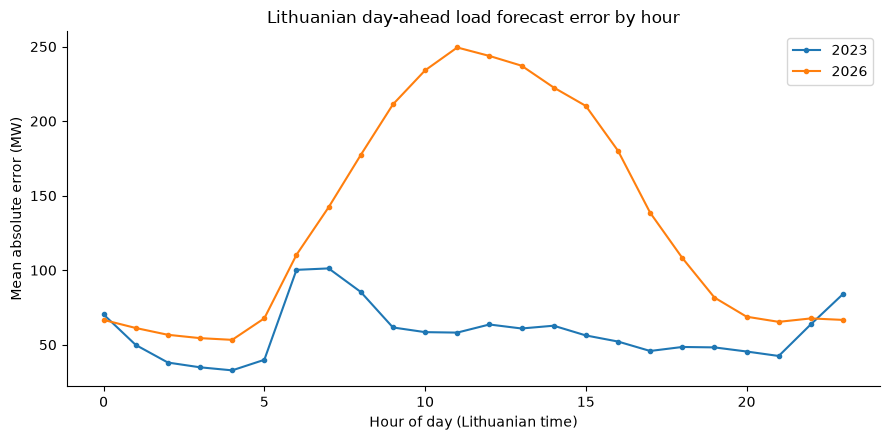

Share of hours with a forecast, % (neighbouring zones):


load_fc_mw                             wind_fc_mw                       \
year        2022   2023   2024   2025   2026       2022   2023   2024   2025   
zone                                                                           
DE_LU      100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
EE         100.0  100.0   99.4   99.0  100.0      100.0   99.7  100.0   99.7   
FI         100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
LV         100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
PL         100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
SE_3       100.0  100.0  100.0   99.7  100.0      100.0  100.0  100.0   99.2   
SE_4       100.0  100.0  100.0   99.7  100.0      100.0  100.0  100.0   99.2   

             solar_fc_mw                              
year    2026        2022   2023   2024   2025   2026  
zone                                                  
DE_LU  100.0       100.0  100.0  100.0  100.0  100.0  
EE      99.6       100.0   99.7  100.0   99.7   99.6  
FI     100.0       100.0  100.0  100.0   99.7  100.0  
LV     100.0         0.0    0.0   73.5  100.0  100.0  
PL     100.0       100.0  100.0  100.0  100.0  100.0  
SE_3    98.9       100.0  100.0  100.0   99.2   98.9  
SE_4    98.9       100.0  100.0  100.0   99.2   98.9

In [3]:
lt["year"] = lt["ts_local"].dt.year
errors = pd.DataFrame({
    "load": (lt["load_forecast_mw"] - lt["load_mw"]).abs(),
    "wind": (lt["wind_forecast_mw"] - lt["wind_mw"]).abs(),
    "solar": (lt["solar_forecast_mw"] - lt["solar_mw"]).abs(),
})
mae_mw = errors.groupby(lt["year"]).mean()
actual = lt.groupby("year")[["load_mw", "wind_mw", "solar_mw"]].mean().set_axis(mae_mw.columns, axis=1)
quality = pd.concat({"MAE, MW": mae_mw, "MAE, % of actual average": 100 * mae_mw / actual}, axis=1)
display(quality.round(1))

by_hour = errors["load"].groupby([lt["year"], lt["ts_local"].dt.hour]).mean().unstack(0)
fig, ax = plt.subplots()
for year in [by_hour.columns.min(), by_hour.columns.max()]:
    ax.plot(by_hour.index, by_hour[year], marker="o", ms=3, label=str(year))
ax.set_xlabel("Hour of day (Lithuanian time)")
ax.set_ylabel("Mean absolute error (MW)")
ax.set_title("Lithuanian day-ahead load forecast error by hour")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q3_load_forecast_error.png", dpi=150)
plt.show()

coverage = (zones.assign(year=zones["ts_utc"].dt.year)
                 .groupby(["zone", "year"])[["load_fc_mw", "wind_fc_mw", "solar_fc_mw"]]
                 .agg(lambda s: 100 * s.notna().mean()))
print("Share of hours with a forecast, % (neighbouring zones):")
coverage.round(1).unstack("year")

## 2. Building the data on the auction's clock

**Regions.** The neighbours' forecasts are summed into regions: Baltic (Latvia, Estonia), Nordic (Finland, SE3,
SE4), Poland and Germany. Latvian solar forecasts only start in 2024, so Baltic solar is Estonia's. Short gaps
(up to 3 hours) are filled with the last known value and longer ones with the same hour a day earlier — only
past values, so nothing from later hours leaks in. The residual load forecast (load − wind − solar) of each region
is added for LightGBM; Lasso, being linear, can form it from its parts.

**For H9**, the variants replace forecasts with values nobody knows before the auction: the actual Lithuanian wind,
solar and load, or ERA5 reanalysis wind put on the forecast's MW scale with a line fitted on the previous 90 days.

In [4]:
TZ_AUCTION = "Europe/Brussels"
ts_cet = lt["ts_utc"].dt.tz_localize("UTC").dt.tz_convert(TZ_AUCTION)
lt["day"] = ts_cet.dt.tz_localize(None).dt.normalize()
lt["hour"] = ts_cet.dt.hour
DAYS = pd.date_range(lt["day"].min() + pd.Timedelta(days=1), lt["day"].max(), freq="D")  # the first CET day is partial


def fill_gaps(frame):
    # Fill gaps with past values only: up to 3 hours with the last value, longer ones with the same hour a day earlier.
    frame = frame.ffill(limit=3)
    for _ in range(7):
        frame = frame.fillna(frame.shift(24))
    return frame


hourly_index = pd.Index(lt["ts_utc"])
SERIES = ["load_fc_mw", "wind_fc_mw", "solar_fc_mw"]
wide = (zones.pivot_table(index="ts_utc", columns="zone", values=SERIES)
             .reindex(index=hourly_index,
                      columns=pd.MultiIndex.from_product([SERIES, sorted(zones["zone"].unique())])))
wide = fill_gaps(wide)

REGIONS = {"baltic": ["LV", "EE"], "nordic": ["FI", "SE_3", "SE_4"], "pl": ["PL"], "de": ["DE_LU"]}
exo_hourly = pd.DataFrame(index=hourly_index)
lt_fc = fill_gaps(lt.set_index("ts_utc")[["load_forecast_mw", "wind_forecast_mw", "solar_forecast_mw"]])
exo_hourly["lt_load"], exo_hourly["lt_wind"], exo_hourly["lt_solar"] = (lt_fc[c] for c in lt_fc.columns)
for region, members in REGIONS.items():
    solar_members = [z for z in members if z != "LV"]
    exo_hourly[f"{region}_load"] = wide["load_fc_mw"][members].sum(axis=1, min_count=len(members))
    exo_hourly[f"{region}_wind"] = wide["wind_fc_mw"][members].sum(axis=1, min_count=len(members))
    exo_hourly[f"{region}_solar"] = wide["solar_fc_mw"][solar_members].sum(axis=1, min_count=len(solar_members))

era5_hourly = pd.DataFrame({
    "lt_wind": lt["wind_cf_lt"].to_numpy(),
    "baltic_wind": lt[["wind_cf_lv", "wind_cf_ee"]].mean(axis=1).to_numpy(),
    "nordic_wind": lt[["wind_cf_fi", "wind_cf_se"]].mean(axis=1).to_numpy(),
    "pl_wind": lt["wind_cf_pl"].to_numpy(),
    "de_wind": lt["wind_cf_de"].to_numpy(),
}, index=hourly_index)


def to_days(values):
    # Hourly values (aligned with lt) -> a table of days x 24 CET hours.
    table = (pd.DataFrame({"day": lt["day"].to_numpy(), "hour": lt["hour"].to_numpy(), "v": np.asarray(values)})
               .pivot_table(index="day", columns="hour", values="v", aggfunc="mean")
               .reindex(index=DAYS, columns=range(24)))
    return table.interpolate(axis=1, limit_area="inside")


P = to_days(lt["price"])
REAL = (lt.pivot_table(index="day", columns="hour", values="price", aggfunc="count")
          .reindex(index=DAYS, columns=range(24)).fillna(0) > 0)          # hours that really exist
NEG = P < 0                                                               # negative-price hours
NEIGH = {n: to_days(lt[f"price_{n}"]) for n in ["ee", "fi", "se4", "pl"]}
EXO = {name: to_days(exo_hourly[name]) for name in exo_hourly.columns}
ERA5 = {name: to_days(era5_hourly[name]) for name in era5_hourly.columns}
ACTUAL = {name: to_days(lt[col]).fillna(EXO[name])
          for name, col in [("lt_wind", "wind_mw"), ("lt_solar", "solar_mw"), ("lt_load", "load_mw")]}


def era5_as_forecast(cf, forecast, window=90):
    # ERA5 wind of day D on the MW scale of the forecast, via a line fitted on days D-window ... D-1 only.
    ok = cf.notna() & forecast.notna()
    x, y = cf.where(ok), forecast.where(ok)
    sums = pd.DataFrame({"n": ok.sum(axis=1), "x": x.sum(axis=1), "y": y.sum(axis=1),
                         "xy": (x * y).sum(axis=1), "xx": (x * x).sum(axis=1)})
    s = sums.rolling(window, min_periods=30).sum().shift(1)            # only days before D
    slope = (s["xy"] - s["x"] * s["y"] / s["n"]) / (s["xx"] - s["x"] ** 2 / s["n"])
    intercept = (s["y"] - slope * s["x"]) / s["n"]
    return cf.mul(slope, axis=0).add(intercept, axis=0).clip(lower=0)


def with_residuals(exo):
    # Add load - wind - solar for every region that has all three.
    exo = dict(exo)
    for r in ["lt", "baltic", "nordic", "pl", "de"]:
        if all(f"{r}_{k}" in exo for k in ("load", "wind", "solar")):
            exo[f"{r}_residual"] = exo[f"{r}_load"] - exo[f"{r}_wind"] - exo[f"{r}_solar"]
    return exo


LOAD = {k: v for k, v in EXO.items() if k.endswith("_load")}
SOLAR = {k: v for k, v in EXO.items() if k.endswith("_solar")}
WIND_FC = {k: v for k, v in EXO.items() if k.endswith("_wind")}
WIND_ERA5 = {name: era5_as_forecast(ERA5[name], EXO[name]) for name in ERA5}
REALISTIC = {**LOAD, **SOLAR, **WIND_FC}
VARIANTS = {
    "no wind or solar forecasts": {**LOAD},
    "ENTSO-E forecasts": with_residuals(REALISTIC),
    "ERA5 wind (reanalysis)": with_residuals({**REALISTIC, **WIND_ERA5}),
    "actual LT wind": with_residuals({**REALISTIC, "lt_wind": ACTUAL["lt_wind"]}),
    "actual LT wind, solar and load": with_residuals({**REALISTIC, **ACTUAL}),
}
MAIN = "ENTSO-E forecasts"

cal = pd.DataFrame(index=DAYS)
cal["weekday"] = DAYS.dayofweek
lt_holidays = holidays.country_holidays("LT", years=range(DAYS.year.min(), DAYS.year.max() + 1))
cal["holiday"] = np.array([d in lt_holidays for d in DAYS.date], dtype=float)
cal["month"] = DAYS.month
cal["doy_sin"], cal["doy_cos"] = np.sin(2 * np.pi * DAYS.dayofyear / 365.25), np.cos(2 * np.pi * DAYS.dayofyear / 365.25)
gas_days = pd.merge_asof(pd.DataFrame({"cutoff": DAYS - pd.Timedelta(days=2)}),
                         gas.assign(trade_date=pd.to_datetime(gas["trade_date"])),
                         left_on="cutoff", right_on="trade_date")
cal["gas"], cal["gas_date"] = gas_days["ttf_eur_mwh"].to_numpy(), gas_days["trade_date"].to_numpy()
hydro_days = pd.merge_asof(pd.DataFrame({"cutoff": DAYS - pd.Timedelta(days=11)}),
                           hydro.assign(week_start=pd.to_datetime(hydro["week_start"])),
                           left_on="cutoff", right_on="week_start")
cal["hydro"], cal["hydro_week"] = hydro_days["deviation_gwh"].to_numpy() / 1000, hydro_days["week_start"].to_numpy()
cal["estlink2_out"] = ((DAYS >= "2024-12-25") & (DAYS < "2025-06-20")).astype(float)
print(f"{len(DAYS):,} delivery days from {DAYS[0].date()} to {DAYS[-1].date()}")

1,365 delivery days from 2023-01-01 to 2026-09-26


### 2.1 Information-set checks
Automatic checks that no feature of the realistic model uses information from after the auction.

In [5]:
assert (cal["gas_date"].isna() | (cal["gas_date"] <= cal.index - pd.Timedelta(days=2))).all(), "gas price from after the auction"
assert (cal["hydro_week"].isna() | (cal["hydro_week"] <= cal.index - pd.Timedelta(days=11))).all(), "hydro data not yet published"
day = TEST[0] + pd.Timedelta(days=10)
assert P.shift(1).loc[day, 7] == P.loc[day - pd.Timedelta(days=1), 7], "price lag misaligned"
print("Gas: the latest close used is always at least two days before delivery.")
print("Hydro: the latest week used always started at least 11 days before delivery.")
print(f"Prices: the feature 'yesterday, hour 7' for {day.date()} is the price of {(day - pd.Timedelta(days=1)).date()} hour 7.")
print("Neighbours' prices: only D-1. Actual values and ERA5 appear only in the H9 comparison variants.")

Gas: the latest close used is always at least two days before delivery.
Hydro: the latest week used always started at least 11 days before delivery.
Prices: the feature 'yesterday, hour 7' for 2026-01-11 is the price of 2026-01-10 hour 7.
Neighbours' prices: only D-1. Actual values and ERA5 appear only in the H9 comparison variants.


## 3. The models

**Naive benchmark** (standard in price forecasting): for Tuesday–Friday the same hour yesterday, for
Monday, Saturday and Sunday the same hour a week ago.

**Lasso (LEAR).** One linear model per delivery hour, with the full price curves of D−1, D−2 and D−7, the
neighbours' prices of D−1, the forecasts for that hour and their daily means, gas, hydro, the Estlink 2 outage,
holidays, weekdays and the season. Lasso keeps only the useful features (penalty chosen by AIC). Prices are
transformed with a scaled asinh (median and spread of the training window) before fitting. Three models with 182,
364 and 728 days of history are averaged: short windows adapt faster, long ones are more stable.

*Safeguards.* A per-hour model can meet a feature that barely varied in its training window — for example a solar
forecast at night, which is almost always zero. One unusual value then becomes thousands of standard deviations
and the forecast explodes. So features that (almost) never vary in the window are dropped, inputs are capped at
±5 standard deviations, and the forecast is capped just outside the range of prices seen in training. The notebook
counts how often the caps are used.

**LightGBM.** One gradient-boosted tree model for all hours, with the hour as a feature and the residual load
forecasts added. It picks up non-linear effects such as the concave wind effect from question 1, but cannot
extrapolate beyond values seen in training. Its settings (L1 or L2 loss, tree size, regularisation, and whether
recent months weigh more) are chosen on the validation period.

**Ensemble (main model).** The simple average of Lasso and LightGBM, fixed in advance.

In [6]:
def asinh_params(values):
    # Median and robust spread of prices, for the scaled asinh transform.
    values = values[np.isfinite(values)]
    a = np.median(values)
    b = 1.4826 * np.median(np.abs(values - a))
    return a, max(b, 1.0)


def to_asinh(x, a, b):
    return np.arcsinh((x - a) / b)


def from_asinh(z, a, b):
    return a + b * np.sinh(z)


def naive_forecast():
    # Same hour yesterday on Tuesday-Friday, same hour a week ago on Monday, Saturday and Sunday.
    naive = P.shift(1).copy()
    week_ago = P.index.dayofweek.isin([0, 5, 6])
    naive.loc[week_ago] = P.shift(7).loc[week_ago]
    return naive


def lasso_design(h, exo):
    # Features of the Lasso model for delivery hour h, one row per day (residual load is left out: Lasso is linear).
    parts = [P.shift(1).add_prefix("p_d1_"), P.shift(2).add_prefix("p_d2_"), P.shift(7).add_prefix("p_d7_")]
    for n, table in NEIGH.items():
        parts += [table.shift(1)[h].rename(f"{n}_d1_h"), table.shift(1).mean(axis=1).rename(f"{n}_d1_mean")]
    for name, table in exo.items():
        if not name.endswith("_residual"):
            parts += [table[h].rename(f"{name}_h"), table.mean(axis=1).rename(f"{name}_mean")]
    parts += [cal[["gas", "hydro", "estlink2_out", "holiday", "doy_sin", "doy_cos"]],
              pd.get_dummies(cal["weekday"], prefix="wd", drop_first=True).astype(float)]
    return pd.concat(parts, axis=1)


def lgb_design(exo):
    # Features of the LightGBM model, one row per delivery day and hour.
    rows = []
    for h in range(24):
        d = pd.DataFrame(index=DAYS)
        d["hour"] = h
        d["p_d1_h"], d["p_d2_h"], d["p_d7_h"] = P.shift(1)[h], P.shift(2)[h], P.shift(7)[h]
        d["p_d1_mean"], d["p_d1_min"], d["p_d1_max"] = P.shift(1).mean(axis=1), P.shift(1).min(axis=1), P.shift(1).max(axis=1)
        for n, table in NEIGH.items():
            d[f"{n}_d1_h"], d[f"{n}_d1_mean"] = table.shift(1)[h], table.shift(1).mean(axis=1)
        for name, table in exo.items():
            d[f"{name}_h"], d[f"{name}_mean"] = table[h], table.mean(axis=1)
        d = d.join(cal[["weekday", "holiday", "month", "doy_sin", "doy_cos", "gas", "hydro", "estlink2_out"]])
        d["target"], d["real"] = P[h], REAL[h]
        rows.append(d)
    return pd.concat(rows).rename_axis("day").reset_index()


DESIGN = {}
for variant, exo in VARIANTS.items():
    lasso_x = {h: lasso_design(h, exo) for h in range(24)}
    lgb_x = lgb_design(exo)
    DESIGN[variant] = {
        "lasso": {h: x.to_numpy(dtype=float) for h, x in lasso_x.items()},
        "lasso_price_cols": np.array([c.startswith(("p_d", "ee_", "fi_", "se4_", "pl_d")) for c in lasso_x[0].columns]),
        "lgb": lgb_x,
        "lgb_features": [c for c in lgb_x.columns if c not in ("day", "target", "real")],
    }
LGB_FEATURES = DESIGN[MAIN]["lgb_features"]
P_NP = P.to_numpy()
DAY_POS = pd.Series(np.arange(len(DAYS)), index=DAYS)
CLIPS = {"model forecasts": 0, "with an input capped": 0, "with the forecast capped": 0}
print(f"Lasso: {DESIGN[MAIN]['lasso'][0].shape[1]} candidate features per hour; LightGBM: {len(LGB_FEATURES)} features")

Lasso: 122 candidate features per hour; LightGBM: 63 features


In [7]:
def lasso_aic(Z, y, n_alphas=30, max_df_share=None):
    # Lasso path by coordinate descent over 30 penalties; the one with the lowest AIC is kept.
    # max_df_share caps the number of features at that share of the observations (needed for short windows).
    z_mean, y_mean = Z.mean(axis=0), y.mean()
    Zc, yc = Z - z_mean, y - y_mean
    alpha_max = np.abs(Zc.T @ yc).max() / len(yc)
    alphas = alpha_max * np.logspace(0, -3, n_alphas)
    _, coefs, _ = lasso_path(Zc, yc, alphas=alphas)
    rss = ((yc[:, None] - Zc @ coefs) ** 2).sum(axis=0)
    df = (coefs != 0).sum(axis=0)
    aic = len(yc) * np.log(rss / len(yc)) + 2 * df
    if max_df_share is not None:
        aic = np.where(df > max_df_share * len(yc), np.inf, aic)
    coef = coefs[:, np.argmin(aic)]
    return coef, y_mean - z_mean @ coef


def fit_lasso_hour(variant, h, last_train_day, window, max_df_share=None):
    # Train the Lasso model for hour h on `window` days ending at last_train_day.
    X_all, y_all = DESIGN[variant]["lasso"][h], P_NP[:, h]
    price_cols = DESIGN[variant]["lasso_price_cols"]
    end = DAY_POS[last_train_day] + 1
    rows = np.arange(max(0, end - window), end)
    a, b = asinh_params(P_NP[rows].ravel())
    X = X_all[rows].copy()
    X[:, price_cols] = to_asinh(X[:, price_cols], a, b)
    y = to_asinh(y_all[rows], a, b)
    keep = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[keep], y[keep]
    mu, sd = X.mean(axis=0), X.std(axis=0)
    mode_share = np.array([np.unique(col, return_counts=True)[1].max() / len(col) for col in X.T])
    use = (sd > 1e-9) & (mode_share < 0.99)              # drop features that (almost) never vary in this window
    Z = np.clip((X[:, use] - mu[use]) / sd[use], -CLIP_SD, CLIP_SD)
    coef, intercept = lasso_aic(Z, y, max_df_share=max_df_share)
    return (coef, intercept), (a, b, mu, sd, use, y.min(), y.max())


def predict_lasso_hour(variant, h, model, params, days):
    a, b, mu, sd, use, y_low, y_high = params
    X = DESIGN[variant]["lasso"][h][DAY_POS[days].to_numpy()].copy()
    price_cols = DESIGN[variant]["lasso_price_cols"]
    X[:, price_cols] = to_asinh(X[:, price_cols], a, b)
    X = np.where(np.isfinite(X), X, mu)                      # a missing feature takes its training mean
    Z = (X[:, use] - mu[use]) / sd[use]
    coef, intercept = model
    z = intercept + np.clip(Z, -CLIP_SD, CLIP_SD) @ coef
    low, high = y_low - 0.5, y_high + 0.5                    # just outside the range seen in training
    CLIPS["model forecasts"] += len(z)
    CLIPS["with an input capped"] += int((np.abs(Z) > CLIP_SD).any(axis=1).sum())
    CLIPS["with the forecast capped"] += int(((z < low) | (z > high)).sum())
    return from_asinh(np.clip(z, low, high), a, b)


def lasso_block(variant, days, last_train_day, windows=None, max_df_share=None):
    # Forecast `days` with Lasso models trained up to last_train_day, averaged over the training windows.
    # One thread for the small matrix algebra: on many machines this is several times faster.
    out = np.zeros((len(days), 24))
    windows = windows or LASSO_WINDOWS
    with threadpool_limits(limits=1):
        for h in range(24):
            for window in windows:
                model, params = fit_lasso_hour(variant, h, last_train_day, window, max_df_share)
                out[:, h] += predict_lasso_hour(variant, h, model, params, days) / len(windows)
    return pd.DataFrame(out, index=days, columns=range(24))


LGB_PARAMS = dict(learning_rate=0.05, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=5.0,
                  random_state=SEED, deterministic=True, force_row_wise=True, verbose=-1, n_jobs=4)


def recency_weights(days, last_train_day, half_life):
    # Weight of a training day: halves every `half_life` days back from the last training day (None = equal weights).
    if half_life is None:
        return None
    return 0.5 ** ((last_train_day - days).dt.days.to_numpy() / half_life)


def fit_lgb(variant, last_train_day, params, n_estimators, half_life):
    data, features = DESIGN[variant]["lgb"], DESIGN[variant]["lgb_features"]
    train = data[(data["day"] <= last_train_day) & data["target"].notna() & data["real"]]
    a, b = asinh_params(train["target"].to_numpy())
    model = lgb.LGBMRegressor(**{**LGB_PARAMS, **params}, n_estimators=n_estimators)
    model.fit(train[features], to_asinh(train["target"].to_numpy(), a, b),
              sample_weight=recency_weights(train["day"], last_train_day, half_life))
    return model, (a, b)


def lgb_block(variant, days, last_train_day, params, n_estimators, half_life):
    model, (a, b) = fit_lgb(variant, last_train_day, params, n_estimators, half_life)
    data, features = DESIGN[variant]["lgb"], DESIGN[variant]["lgb_features"]
    rows = data[data["day"].isin(days)]
    pred = from_asinh(model.predict(rows[features]), a, b)
    table = pd.DataFrame({"day": rows["day"], "hour": rows["hour"], "pred": pred})
    return table.pivot(index="day", columns="hour", values="pred").reindex(index=days, columns=range(24)), model


def blocks(first, last, every):
    # Split the forecast period into blocks; each block is forecast by models trained up to the day before it.
    days = pd.date_range(first, last, freq="D")
    key = {"D": days, "W": days.to_period("W-SUN").start_time, "M": days.to_period("M").start_time}[every]
    for _, group in pd.Series(days, index=days).groupby(np.asarray(key)):
        yield pd.DatetimeIndex(group.to_numpy())


def walk_forward(model_name, variant, first, last, every, **kw):
    # Forecast every day from first to last, re-training every day/week/month on data before the block.
    t0, parts, last_model = time.time(), [], None
    for days in blocks(first, last, every):
        last_train_day = days[0] - pd.Timedelta(days=1)
        if model_name == "lasso":
            parts.append(lasso_block(variant, days, last_train_day))
        else:
            block, last_model = lgb_block(variant, days, last_train_day, **kw)
            parts.append(block)
    print(f"  {model_name:8s} {variant:31s} {first.date()}–{last.date()}: {time.time() - t0:5.0f} s")
    return pd.concat(parts), last_model

## 4. Choosing LightGBM's settings on the validation period

Step 1 compares the loss function (L2, or L1, which targets the median and is less sensitive to spikes), the size
of the trees and the minimum number of observations per leaf. Step 2 checks whether giving recent months more
weight helps. Each setting is trained once on data up to September 2025 and scored on October–December 2025, with
early stopping choosing the number of trees. The test period plays no part in the choice. Lasso needs no tuning:
its penalty is chosen by AIC every time it is trained.

In [8]:
def mae_on(pred, days, exclude=None):
    # MAE over the real hours of `days` (optionally leaving out the hours marked in `exclude`).
    mask = REAL.reindex(days)
    if exclude is not None:
        mask = mask & ~exclude.reindex(days).fillna(False)
    err = (pred.reindex(days) - P.reindex(days)).where(mask)
    return np.nanmean(np.abs(err.to_numpy()))


data = DESIGN[MAIN]["lgb"]
train = data[(data["day"] <= TRAIN_END) & data["target"].notna() & data["real"]]
valid = data[data["day"].between(*VALID) & data["target"].notna() & data["real"]]
a, b = asinh_params(train["target"].to_numpy())
valid_days = pd.date_range(*VALID, freq="D")


def try_setting(params, half_life):
    model = lgb.LGBMRegressor(**LGB_PARAMS, **params, n_estimators=3000)
    model.fit(train[LGB_FEATURES], to_asinh(train["target"].to_numpy(), a, b),
              sample_weight=recency_weights(train["day"], TRAIN_END, half_life),
              eval_set=[(valid[LGB_FEATURES], to_asinh(valid["target"].to_numpy(), a, b))],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    pred = from_asinh(model.predict(valid[LGB_FEATURES]), a, b)
    return {**params, "half_life": half_life, "trees": model.best_iteration_,
            "validation MAE": np.mean(np.abs(pred - valid["target"]))}


grid = [{"objective": "regression_l1", "num_leaves": 31, "min_child_samples": 50}] if FAST else [
    {"objective": obj, "num_leaves": nl, "min_child_samples": mcs}
    for obj in ("regression", "regression_l1") for nl in (15, 31) for mcs in (50, 200)]
step1 = pd.DataFrame([try_setting(params, None) for params in grid]).sort_values("validation MAE")
best = step1.iloc[0]
best_params = {"objective": best["objective"], "num_leaves": int(best["num_leaves"]),
               "min_child_samples": int(best["min_child_samples"])}
step2 = pd.DataFrame([try_setting(best_params, hl) for hl in ([None] if FAST else [None, 365, 180])])
best2 = step2.sort_values("validation MAE").iloc[0]
LGB_SETTINGS = {"params": best_params, "n_estimators": int(best2["trees"]),
                "half_life": None if pd.isna(best2["half_life"]) else float(best2["half_life"])}
print("Chosen:", LGB_SETTINGS)
display(step1.round(2))
step2.round(2)

Chosen: {'params': {'objective': 'regression', 'num_leaves': 31, 'min_child_samples': 200}, 'n_estimators': 529, 'half_life': 365.0}


,objective,num_leaves,min_child_samples,half_life,trees,validation MAE
3,regression,31,200,None,122,29.77
0,regression,15,50,None,258,29.83
6,regression_l1,31,50,None,412,29.87
2,regression,31,50,None,194,29.93
1,regression,15,200,None,138,30.13
7,regression_l1,31,200,None,231,30.37
5,regression_l1,15,200,None,451,30.59
4,regression_l1,15,50,None,277,30.67


,objective,num_leaves,min_child_samples,half_life,trees,validation MAE
0,regression,31,200,NaN,122,29.77
1,regression,31,200,365.0,529,29.02
2,regression,31,200,180.0,275,29.10


## 5. H8 — Forecasting January–August 2026

The validation and test periods are forecast day by day. Lasso is re-trained every day and LightGBM every week,
always on data before the forecast day. This is one of the two long steps (roughly 10–20 minutes; set `FAST = True`
at the top for a quick run of a few minutes).

In [9]:
t_start = time.time()
forecasts = {}
forecasts["Naive"] = naive_forecast()
first, last = VALID[0], TEST[1]
forecasts["Lasso"], _ = cached("v1_lasso", lambda: walk_forward("lasso", MAIN, first, last, LASSO_EVERY))
forecasts["LightGBM"], lgb_last_model = cached(
    "v1_lightgbm", lambda: walk_forward("lightgbm", MAIN, first, last, LGB_EVERY, **LGB_SETTINGS))
forecasts["Ensemble"] = (forecasts["Lasso"] + forecasts["LightGBM"]) / 2
print(f"Done in {(time.time() - t_start) / 60:.1f} minutes")
if CLIPS["model forecasts"]:
    print(f"Lasso safeguards: of {CLIPS['model forecasts']:,} model forecasts, {CLIPS['with an input capped']:,} had an input "
          f"capped at ±{CLIP_SD} SD and {CLIPS['with the forecast capped']:,} had the forecast capped.")
else:
    print("Lasso safeguards: the counts are shown when the models are re-estimated; "
          "these forecasts were loaded from data/processed/q3_cache.")

  lasso    ENTSO-E forecasts               2025-10-01–2026-08-31:   684 s
  lightgbm ENTSO-E forecasts               2025-10-01–2026-08-31:   182 s
Done in 14.4 minutes
Lasso safeguards: of 24,120 model forecasts, 1,407 had an input capped at ±5 SD and 248 had the forecast capped.


In [10]:
def scores(preds, days):
    # MAE, RMSE and MAE relative to the naive benchmark over the real hours of `days`.
    rows = {}
    for name, pred in preds.items():
        err = (pred.reindex(days) - P.reindex(days)).where(REAL.reindex(days)).to_numpy()
        rows[name] = {"MAE, €/MWh": np.nanmean(np.abs(err)), "RMSE, €/MWh": np.sqrt(np.nanmean(err ** 2))}
    table = pd.DataFrame(rows).T
    table["MAE relative to naive"] = table["MAE, €/MWh"] / table.loc["Naive", "MAE, €/MWh"]
    return table


def dm_test(pred_a, pred_b, days):
    # Diebold-Mariano test on daily mean absolute errors. A negative statistic means A is more accurate.
    real = REAL.reindex(days)
    err_a = (pred_a.reindex(days) - P.reindex(days)).abs().where(real).mean(axis=1)
    err_b = (pred_b.reindex(days) - P.reindex(days)).abs().where(real).mean(axis=1)
    d = (err_a - err_b).dropna()
    fit = sm.OLS(d.to_numpy(), np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
    return pd.Series({"difference in MAE, €/MWh": d.mean(), "DM statistic": fit.tvalues[0], "p_value": fit.pvalues[0]})


test_days = pd.date_range(*TEST, freq="D")
test_scores = scores(forecasts, test_days)
display(test_scores.round(3))

dm = pd.DataFrame({
    "Ensemble vs Naive": dm_test(forecasts["Ensemble"], forecasts["Naive"], test_days),
    "Ensemble vs Lasso": dm_test(forecasts["Ensemble"], forecasts["Lasso"], test_days),
    "Ensemble vs LightGBM": dm_test(forecasts["Ensemble"], forecasts["LightGBM"], test_days),
    "Lasso vs Naive": dm_test(forecasts["Lasso"], forecasts["Naive"], test_days),
    "LightGBM vs Naive": dm_test(forecasts["LightGBM"], forecasts["Naive"], test_days),
}).T
show_p(dm.round(3))

,"MAE, €/MWh","RMSE, €/MWh",MAE relative to naive
Naive,41.799,61.270,1.000
Lasso,27.510,39.591,0.658
LightGBM,25.097,36.640,0.600
Ensemble,24.568,35.648,0.588


,"difference in MAE, €/MWh",DM statistic,p_value
Ensemble vs Naive,-17.233,-9.811,<0.001
Ensemble vs Lasso,-2.942,-6.615,<0.001
Ensemble vs LightGBM,-0.531,-1.306,0.191
Lasso vs Naive,-14.292,-8.650,<0.001
LightGBM vs Naive,-16.703,-8.821,<0.001


### 5.1 In sample against out of sample
The same models, trained once on data up to September 2025, scored on the last six months of their own training
data (in sample), and the walk-forward scores on the validation and test periods (out of sample). A model whose
in-sample error is far below its out-of-sample error is overfitted.

In [11]:
in_days = pd.date_range(TRAIN_END - pd.Timedelta(days=181), TRAIN_END, freq="D")
in_sample = {"Naive": forecasts["Naive"], "Lasso": lasso_block(MAIN, in_days, TRAIN_END)}
in_sample["LightGBM"], _ = lgb_block(MAIN, in_days, TRAIN_END, **LGB_SETTINGS)
in_sample["Ensemble"] = (in_sample["Lasso"] + in_sample["LightGBM"]) / 2
overfit = pd.DataFrame({
    "in sample (Apr–Sep 2025)": scores(in_sample, in_days)["MAE, €/MWh"],
    "validation (Oct–Dec 2025)": scores(forecasts, valid_days)["MAE, €/MWh"],
    "test (Jan–Aug 2026)": test_scores["MAE, €/MWh"],
})
overfit.round(2)

,in sample (Apr–Sep 2025),validation (Oct–Dec 2025),test (Jan–Aug 2026)
Naive,34.42,55.06,41.80
Lasso,17.65,30.99,27.51
LightGBM,10.48,28.58,25.10
Ensemble,12.92,28.30,24.57


### 5.2 Where the errors are

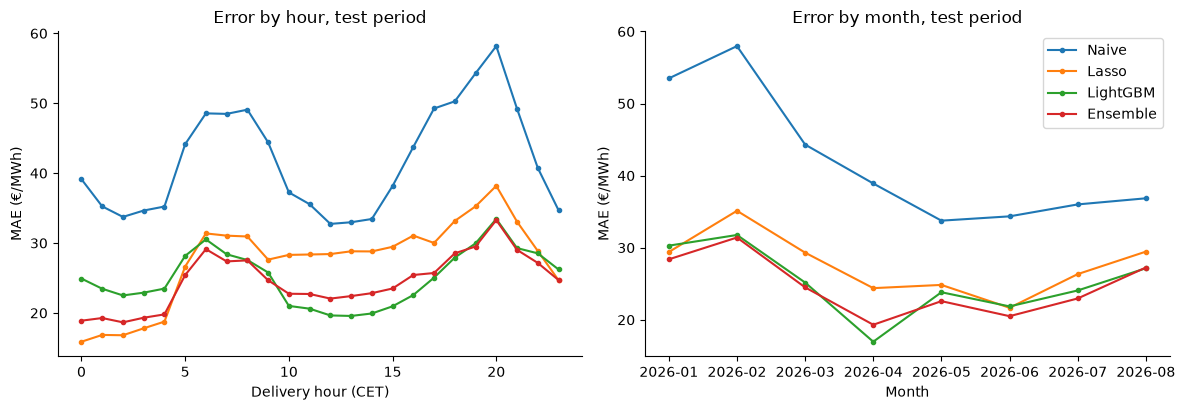

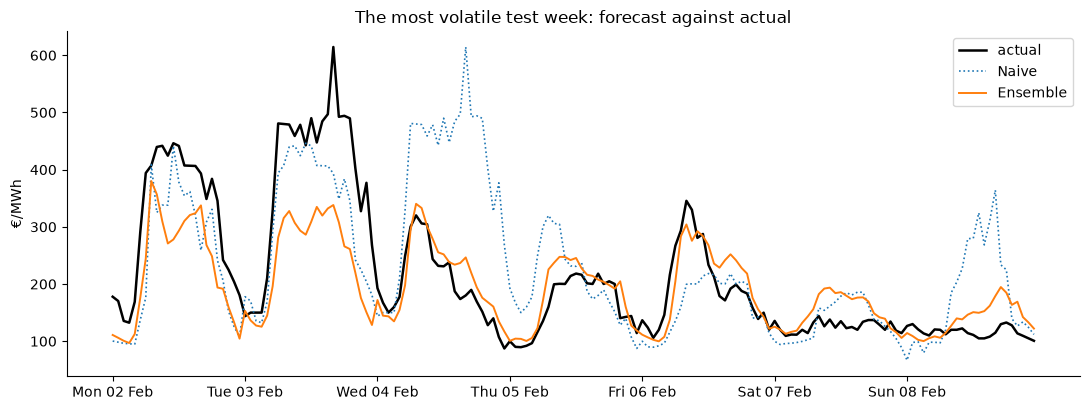

In [12]:
def mae_by(pred, days, key):
    real = REAL.reindex(days)
    err = (pred.reindex(days) - P.reindex(days)).abs().where(real)
    if key == "hour":
        return err.mean(axis=0)
    daily = err.mean(axis=1)
    return daily.groupby(daily.index.to_period("M")).mean()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name in ["Naive", "Lasso", "LightGBM", "Ensemble"]:
    axes[0].plot(range(24), mae_by(forecasts[name], test_days, "hour"), marker="o", ms=3, label=name)
    monthly = mae_by(forecasts[name], test_days, "month")
    axes[1].plot(monthly.index.astype(str), monthly.to_numpy(), marker="o", ms=3, label=name)
axes[0].set(xlabel="Delivery hour (CET)", ylabel="MAE (€/MWh)", title="Error by hour, test period")
axes[1].set(xlabel="Month", ylabel="MAE (€/MWh)", title="Error by month, test period")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "q3_error_by_hour_month.png", dpi=150)
plt.show()

# the test week with the largest price swings
test_prices = P.reindex(test_days).where(REAL.reindex(test_days))
weekly_spread = test_prices.groupby(test_days.to_period("W-SUN")).apply(lambda g: np.nanstd(g.to_numpy()))
week = weekly_spread.idxmax()
week_days = pd.date_range(week.start_time, week.end_time.normalize(), freq="D")
fig, ax = plt.subplots(figsize=(11, 4.2))
for name, style in [("actual", dict(color="black", lw=1.8)), ("Naive", dict(ls=":", lw=1.2)),
                    ("Ensemble", dict(lw=1.4))]:
    table = P if name == "actual" else forecasts[name]
    series = table.reindex(week_days).where(REAL.reindex(week_days)).to_numpy().ravel()
    ax.plot(range(len(series)), series, label=name, **style)
ax.set_xticks(range(0, 24 * len(week_days), 24), [d.strftime("%a %d %b") for d in week_days])
ax.set_ylabel("€/MWh")
ax.set_title("The most volatile test week: forecast against actual")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q3_example_week.png", dpi=150)
plt.show()

### 5.3 What drives the LightGBM forecast
Gain importance in the last LightGBM model of the test period: how much each feature improves the fit. It shows
what the model relies on, not causal effects (question 1 covers those).

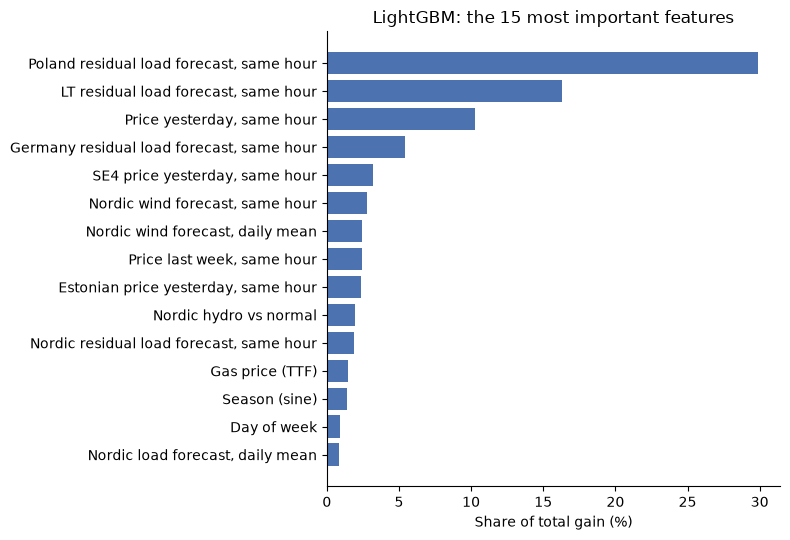

In [13]:
REGION_NAMES = {"lt": "LT", "baltic": "Baltic", "nordic": "Nordic", "pl": "Poland", "de": "Germany"}
KINDS = {"load": "load forecast", "wind": "wind forecast", "solar": "solar forecast", "residual": "residual load forecast"}
PRICE_NAMES = {"ee": "Estonian", "fi": "Finnish", "se4": "SE4", "pl": "Polish"}
SIMPLE = {"p_d1_h": "Price yesterday, same hour", "p_d2_h": "Price 2 days ago, same hour",
          "p_d7_h": "Price last week, same hour", "p_d1_mean": "Price yesterday, daily mean",
          "p_d1_min": "Price yesterday, daily minimum", "p_d1_max": "Price yesterday, daily maximum",
          "hour": "Hour of day", "weekday": "Day of week", "holiday": "Holiday", "month": "Month",
          "doy_sin": "Season (sine)", "doy_cos": "Season (cosine)", "gas": "Gas price (TTF)",
          "hydro": "Nordic hydro vs normal", "estlink2_out": "Estlink 2 outage", "eua": "Carbon price proxy (EUA)"}


def readable(name):
    # A plain-English label for a feature name.
    if name in SIMPLE:
        return SIMPLE[name]
    if name.startswith("ntc_"):
        core, suffix = name[4:].rsplit("_", 1)
        origin, destination = core.split("_to_")
        return (f"Capacity {origin.upper().replace('_', '')} → {destination.upper().replace('_', '')}, "
                + ("same hour" if suffix == "h" else "daily mean"))
    head, *rest = name.split("_")
    if head in PRICE_NAMES and rest[0] == "d1":
        return f"{PRICE_NAMES[head]} price yesterday, " + ("same hour" if rest[1] == "h" else "daily mean")
    if head in REGION_NAMES and rest and rest[0] in KINDS:
        label, tail = f"{REGION_NAMES[head]} {KINDS[rest[0]]}", rest[1:]
        for key, words in [("d1", " for yesterday"), ("chg", ", change from yesterday"), ("sq", ", squared")]:
            if tail[:1] == [key]:
                label, tail = label + words, tail[1:]
        return label + {"h": ", same hour", "mean": ", daily mean"}.get(tail[0] if tail else "", "")
    return name


importance = (pd.Series(lgb_last_model.booster_.feature_importance("gain"), index=LGB_FEATURES)
                .sort_values(ascending=False))
top = (100 * importance / importance.sum()).head(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh([readable(n) for n in top.index[::-1]], top.to_numpy()[::-1], color="#4c72b0")
ax.set_xlabel("Share of total gain (%)")
ax.set_title("LightGBM: the 15 most important features")
fig.tight_layout()
fig.savefig(FIG / "q3_feature_importance.png", dpi=150)
plt.show()

## 6. H9 — How much would better information be worth?

The same models over the test period, identical except for one kind of information:

- **no wind or solar forecasts** — only load forecasts, prices and calendar (a lower bound);
- **ENTSO-E forecasts** — the realistic information set;
- **ERA5 wind (reanalysis)** — the wind forecasts replaced by reanalysis wind of the same day, on the same MW scale;
- **actual LT wind** — Lithuania's wind forecast replaced by the wind output that actually occurred;
- **actual LT wind, solar and load** — all three Lithuanian forecasts replaced by what actually occurred.

The gap between the ENTSO-E and the "actual" versions is the accuracy lost to Lithuanian forecast errors. Actual
wind output is lower when farms stop at negative prices (question 2), which hints at the price, so every variant is
also scored without negative-price hours. To keep the run time manageable, both models are re-trained monthly
here, so the ENTSO-E version differs slightly from the main model above; all five versions are treated alike.

In [14]:
h9_every = "M"  # monthly re-training keeps this comparison to a few minutes
h9 = {}
for i, variant in enumerate(VARIANTS):
    lasso_pred = cached(f"h9_lasso_{i}", lambda: pd.concat([lasso_block(variant, days, days[0] - pd.Timedelta(days=1))
                                                          for days in blocks(*TEST, h9_every)]))
    lgb_pred, _ = cached(f"h9_lightgbm_{i}", lambda: walk_forward("lightgbm", variant, *TEST, h9_every, **LGB_SETTINGS))
    h9[variant] = {"Lasso": lasso_pred, "LightGBM": lgb_pred, "Ensemble": (lasso_pred + lgb_pred) / 2}

h9_mae = pd.DataFrame({
    v: {**{m: mae_on(p, test_days) for m, p in models.items()},
        "Ensemble, without negative-price hours": mae_on(models["Ensemble"], test_days, exclude=NEG)}
    for v, models in h9.items()
}).T
h9_dm = pd.DataFrame({
    f"{v} vs ENTSO-E forecasts": dm_test(h9[v]["Ensemble"], h9[MAIN]["Ensemble"], test_days)
    for v in VARIANTS if v != MAIN
}).T
display(h9_mae.round(2))
show_p(h9_dm.round(3))

  lightgbm no wind or solar forecasts      2026-01-01–2026-08-31:    17 s
  lightgbm ENTSO-E forecasts               2026-01-01–2026-08-31:    27 s
  lightgbm ERA5 wind (reanalysis)          2026-01-01–2026-08-31:    27 s
  lightgbm actual LT wind                  2026-01-01–2026-08-31:    22 s
  lightgbm actual LT wind, solar and load  2026-01-01–2026-08-31:    23 s


,Lasso,LightGBM,Ensemble,"Ensemble, without negative-price hours"
no wind or solar forecasts,31.57,33.38,30.26,30.35
ENTSO-E forecasts,30.66,27.49,27.09,27.05
ERA5 wind (reanalysis),31.64,29.12,28.42,28.39
actual LT wind,31.75,27.74,27.77,27.77
"actual LT wind, solar and load",31.53,28.07,27.79,27.81


,"difference in MAE, €/MWh",DM statistic,p_value
no wind or solar forecasts vs ENTSO-E forecasts,3.172,3.797,<0.001
ERA5 wind (reanalysis) vs ENTSO-E forecasts,1.328,3.019,0.003
actual LT wind vs ENTSO-E forecasts,0.674,1.849,0.064
"actual LT wind, solar and load vs ENTSO-E forecasts",0.702,1.926,0.054


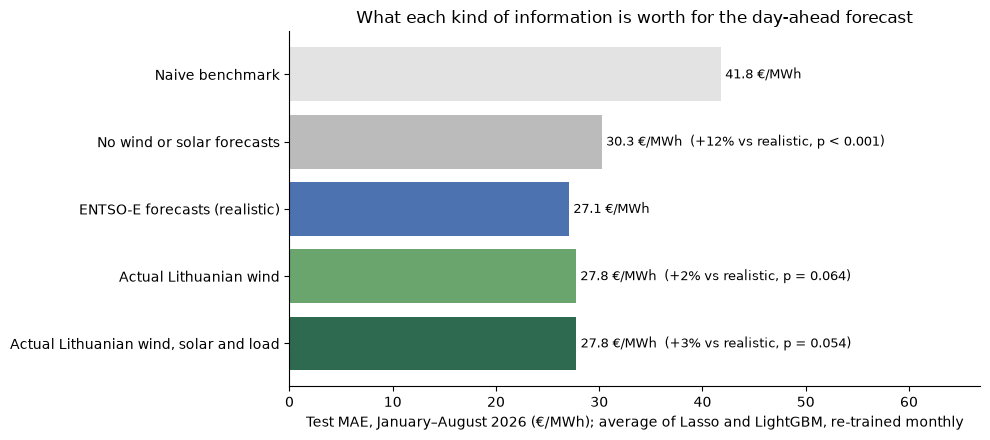

In [15]:
order = ["no wind or solar forecasts", "ENTSO-E forecasts", "actual LT wind", "actual LT wind, solar and load"]
labels = ["Naive benchmark", "No wind or solar forecasts", "ENTSO-E forecasts (realistic)",
          "Actual Lithuanian wind", "Actual Lithuanian wind, solar and load"]
naive_mae = test_scores.loc["Naive", "MAE, €/MWh"]
values = [naive_mae] + list(h9_mae.loc[order, "Ensemble"])
base = h9_mae.loc[MAIN, "Ensemble"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(range(len(values)), values, color=["#e3e3e3", "#bbbbbb", "#4c72b0", "#6aa56e", "#2d6a4f"])
for i, v in enumerate(values):
    name = None if i == 0 else order[i - 1]
    if name in (None, MAIN):
        text = f"{v:.1f} €/MWh"
    else:
        p_value = h9_dm.loc[f"{name} vs ENTSO-E forecasts", "p_value"]
        text = f"{v:.1f} €/MWh  ({100 * (v / base - 1):+.0f}% vs realistic, {fmt_p(p_value)})"
    ax.text(v + 0.4, i, text, va="center", fontsize=9)
ax.set_yticks(range(len(values)), labels)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.6)
ax.set_xlabel("Test MAE, January–August 2026 (€/MWh); average of Lasso and LightGBM, re-trained monthly")
ax.set_title("What each kind of information is worth for the day-ahead forecast")
fig.tight_layout()
fig.savefig(FIG / "q3_h9_information_value.png", dpi=150)
plt.show()

### 6.1 How much of the price error comes from Lithuanian forecast errors?

A second view of H9: the ensemble's hourly price error over the test period regressed on the errors of the three
Lithuanian forecasts (forecast minus actual, per 100 MW). A negative wind coefficient means: when the wind forecast
was too high, the price forecast was too low. The R² is the share of the price error's variance that the Lithuanian
forecast errors explain — a lower bound for all forecast errors, since the neighbours' errors are not included.

In [16]:
def flat(table, days):
    return table.reindex(days).where(REAL.reindex(days)).to_numpy().ravel()


att = pd.DataFrame({
    "price_error": flat(forecasts["Ensemble"] - P, test_days),
    "wind_error": flat((EXO["lt_wind"] - ACTUAL["lt_wind"]) / 100, test_days),
    "solar_error": flat((EXO["lt_solar"] - ACTUAL["lt_solar"]) / 100, test_days),
    "load_error": flat((EXO["lt_load"] - ACTUAL["lt_load"]) / 100, test_days),
}).dropna()
m_att = sm.OLS(att["price_error"], sm.add_constant(att[["wind_error", "solar_error", "load_error"]])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 24})
attribution = pd.DataFrame({
    "€/MWh per 100 MW forecast error": m_att.params, "ci_low": m_att.conf_int()[0],
    "ci_high": m_att.conf_int()[1], "p_value": m_att.pvalues,
}).drop("const")
print(f"Lithuanian forecast errors explain {100 * m_att.rsquared:.1f}% of the variance of the price forecast error.")

daily = pd.DataFrame({
    "price MAE": (forecasts["Ensemble"] - P).abs().where(REAL).reindex(test_days).mean(axis=1),
    "wind error": (EXO["lt_wind"] - ACTUAL["lt_wind"]).abs().reindex(test_days).mean(axis=1),
})
daily["wind forecast error"] = pd.qcut(daily["wind error"].rank(method="first"), 5,
                                      labels=["smallest 20%", "2", "3", "4", "largest 20%"])
display(daily.groupby("wind forecast error", observed=True)[["wind error", "price MAE"]].mean()
             .rename(columns={"wind error": "mean wind forecast error, MW", "price MAE": "price MAE, €/MWh"}).round(1))
show_p(attribution.round(3))

Lithuanian forecast errors explain 0.1% of the variance of the price forecast error.


,"mean wind forecast error, MW","price MAE, €/MWh"
wind forecast error,,
smallest 20%,55.8,24.1
2,86.3,24.5
3,115.3,23.1
4,164.7,21.7
largest 20%,302.1,29.4


,€/MWh per 100 MW forecast error,ci_low,ci_high,p_value
wind_error,-0.289,-1.561,0.984,0.657
solar_error,-0.720,-2.064,0.625,0.294
load_error,0.157,-0.970,1.284,0.785


## 7. Summary of H8–H9

H8 is supported when the ensemble's test MAE is below the naive benchmark's and the Diebold–Mariano test finds the
difference significant (p < 0.05). H9 is supported when the version with the actual Lithuanian wind output is
significantly more accurate than the ENTSO-E version.

In [27]:
h8 = dm.loc["Ensemble vs Naive"]
h8_ok = h8["difference in MAE, €/MWh"] < 0 and h8["p_value"] < 0.05
h9_test = h9_dm.loc["actual LT wind vs ENTSO-E forecasts"]
h9_ok = h9_test["difference in MAE, €/MWh"] < 0 and h9_test["p_value"] < 0.05
def change(new, old):
    # "12% lower" or "3% higher": the relative change from old to new.
    pct = 100 * (new / old - 1)
    return f"{abs(pct):.0f}% {'higher' if pct > 0 else 'lower'}"


summary = pd.DataFrame([
    ["H8", "The model beats the naive benchmark",
     f"ensemble MAE {test_scores.loc['Ensemble', 'MAE, €/MWh']:.2f} vs naive {test_scores.loc['Naive', 'MAE, €/MWh']:.2f} €/MWh "
     f"({change(test_scores.loc['Ensemble', 'MAE, €/MWh'], test_scores.loc['Naive', 'MAE, €/MWh'])}, DM {fmt_p(h8['p_value'])})",
     "supported" if h8_ok else "not supported"],
    ["H9", "Knowing the actual Lithuanian wind output makes the forecast significantly more accurate",
     f"ensemble MAE {h9_mae.loc['actual LT wind', 'Ensemble']:.2f} vs {h9_mae.loc[MAIN, 'Ensemble']:.2f} €/MWh "
     f"({change(h9_mae.loc['actual LT wind', 'Ensemble'], h9_mae.loc[MAIN, 'Ensemble'])}, DM {fmt_p(h9_test['p_value'])}; "
     f"{change(h9_mae.loc['actual LT wind', 'Ensemble, without negative-price hours'], h9_mae.loc[MAIN, 'Ensemble, without negative-price hours'])} "
     "without negative-price hours)",
     "supported" if h9_ok else "not supported"],
], columns=["hypothesis", "statement", "estimate", "verdict"])
summary.to_csv(FIG / "q3_summary.csv", index=False)
display(summary)

top_feature = readable(importance.index[0])
extra = pd.DataFrame([
    ["Ensemble vs LightGBM alone", f"{dm.loc['Ensemble vs LightGBM', 'difference in MAE, €/MWh']:+.2f} €/MWh "
                                   f"({fmt_p(dm.loc['Ensemble vs LightGBM', 'p_value'])})"],
    ["Re-training monthly instead of daily/weekly (ENTSO-E set)",
     f"MAE {h9_mae.loc[MAIN, 'Ensemble']:.1f} vs {test_scores.loc['Ensemble', 'MAE, €/MWh']:.1f} €/MWh "
     f"({change(h9_mae.loc[MAIN, 'Ensemble'], test_scores.loc['Ensemble', 'MAE, €/MWh'])})"],
    ["ERA5 reanalysis wind instead of the operators' forecasts",
     f"MAE {h9_mae.loc['ERA5 wind (reanalysis)', 'Ensemble']:.1f} vs {h9_mae.loc[MAIN, 'Ensemble']:.1f} €/MWh "
     f"({fmt_p(h9_dm.loc['ERA5 wind (reanalysis) vs ENTSO-E forecasts', 'p_value'])})"],
    ["Share of the price error explained by Lithuanian forecast errors", f"{100 * m_att.rsquared:.1f}%"],
    ["Most important LightGBM feature", f"{top_feature} ({top.iloc[0]:.0f}% of total gain)"],
], columns=["additional finding", "estimate"])
extra.to_csv(FIG / "q3_followup.csv", index=False)
extra

,hypothesis,statement,estimate,verdict
0,H8,The model beats the naive benchmark,ensemble MAE 24.57 vs naive 41.80 €/MWh (41% l...,supported
1,H9,Knowing the actual Lithuanian wind output make...,"ensemble MAE 27.77 vs 27.09 €/MWh (2% higher, ...",not supported


,additional finding,estimate
0,Ensemble vs LightGBM alone,-0.53 €/MWh (p = 0.191)
1,Re-training monthly instead of daily/weekly (E...,MAE 27.1 vs 24.6 €/MWh (10% higher)
2,ERA5 reanalysis wind instead of the operators'...,MAE 28.4 vs 27.1 €/MWh (p = 0.003)
3,Share of the price error explained by Lithuani...,0.1%
4,Most important LightGBM feature,"Poland residual load forecast, same hour (30% ..."


## 8. Interpretation — write this in your own words

1. How much more accurate is the ensemble than the naive benchmark, in €/MWh and in %? Is the difference significant? How do Lasso and LightGBM compare, and does averaging them help?
2. Is any model overfitted? Compare the in-sample, validation and test errors. Which LightGBM settings were chosen, and what do they say about the data?
3. When do the models miss most — which hours, which months, what kind of days? What does the most volatile week show?
4. Which features does LightGBM rely on most? Does that fit the price drivers from question 1?
5. H9: how much accuracy is lost to Lithuanian forecast errors, and how much do today's forecasts already add? What does the regression of price errors on forecast errors add? Why is ERA5 reanalysis wind no better than the operators' forecasts? What would better forecasts (including of behind-the-meter solar, section 1) be worth to a trading desk?
6. Limits: wind and solar forecasts may be published after the auction (ENTSO-E rules allow until 18:00 on D−1), actual wind output reflects curtailment at negative prices, only Lithuanian actual values are tested, the test covers January–August only, LightGBM cannot extrapolate beyond the training range, question 1 already looked at 2026 data, and point forecasts say nothing about uncertainty.

## 9. An improved model (v2)

A review of the results above found three weak spots: the models adapt slowly when the market changes, they miss
price spikes, and the Lasso barely uses the wind and solar forecasts. v2 addresses them:

1. **Adapt faster.** Lasso also gets 56- and 84-day training windows (averaged with 364 and 728 days); with so few
   days, a model may use at most one feature per three observations. LightGBM is re-trained every day and averages
   two models whose recent months weigh more (half-lives of 180 and 365 days, both good in validation).
2. **Tell the models what changes from yesterday.** The forecasts for D−1 (published on D−2) and the change in
   residual load from D−1 to D. Lasso also gets residual load and its square, so it can bend with the merit-order curve.
3. **Information that explains spikes.** Day-ahead cross-border capacities (published before the auction), a carbon
   price proxy (next to gas, since coal and gas plants often set Poland's price), and the Lithuanian load forecast
   corrected for rooftop solar with a line fitted on the previous 56 days (section 1 found its midday bias).
4. **Combine smarter.** Hour-specific weights for Lasso and LightGBM, estimated on the validation period.
5. **Forecast the uncertainty** (section 10): 80% prediction intervals.

Every choice is made on the validation period (October–December 2025). January–August 2026 has
already been seen, so v2's results there are only indicative. September 2026 was used for nothing and is the clean
test. For speed, v2's LightGBM uses a learning rate of 0.1 with the number of trees chosen by early stopping.

In [28]:
FRESH = (TEST[1] + pd.Timedelta(days=1), DAYS[-1])
HAS_FRESH = (FRESH[1] - FRESH[0]).days >= 6
print(f"Fresh test period: {FRESH[0].date()} – {FRESH[1].date()}" if HAS_FRESH
      else "No data after August 2026: download it to run the fresh test (see the README).")


def rolling_line(x, y, window=56, lag=2):
    # For every day D: slope and intercept of y on x over the `window` days that end at D-lag (all hours pooled).
    ok = x.notna() & y.notna()
    xs, ys = x.where(ok), y.where(ok)
    sums = pd.DataFrame({"n": ok.sum(axis=1), "x": xs.sum(axis=1), "y": ys.sum(axis=1),
                         "xy": (xs * ys).sum(axis=1), "xx": (xs * xs).sum(axis=1)})
    s = sums.rolling(window, min_periods=28).sum().shift(lag)
    slope = (s["xy"] - s["x"] * s["y"] / s["n"]) / (s["xx"] - s["x"] ** 2 / s["n"])
    return slope, (s["y"] - slope * s["x"]) / s["n"]


# 1) the Lithuanian load forecast corrected for rooftop solar: its error is explained by the solar forecast,
#    with a line fitted on days D-57 ... D-2 (the actual load of D-1 is not complete at the auction)
load_error = EXO["lt_load"] - to_days(lt["load_mw"])
slope, intercept = rolling_line(EXO["lt_solar"], load_error)
LT_LOAD_CORRECTED = EXO["lt_load"] - EXO["lt_solar"].mul(slope.fillna(0), axis=0).add(intercept.fillna(0), axis=0)
actual_load = to_days(lt["load_mw"])
def mae_by_year(forecast):
    # Mean absolute error over the real hours of each year.
    err = (forecast - actual_load).abs().where(REAL)
    return pd.Series({y: np.nanmean(err[DAYS.year == y].to_numpy()) for y in sorted(set(DAYS.year))})


check = pd.DataFrame({"forecast as published": mae_by_year(EXO["lt_load"]),
                      "corrected for rooftop solar": mae_by_year(LT_LOAD_CORRECTED)})
print("Lithuanian load forecast, mean absolute error (MW):")
display(check.round(1))

# 2) day-ahead cross-border capacities: every border with a value in at least 90% of the hours
NTC = {}
if len(ntc):
    ntc_wide = fill_gaps(ntc.pivot_table(index="ts_utc", columns="border", values="mw").reindex(hourly_index))
    ntc_cover = {}
    for border in ntc_wide.columns:
        table = to_days(ntc_wide[border])
        ntc_cover[border] = 100 * table.notna().to_numpy().mean()
        if ntc_cover[border] >= 90:
            NTC[f"ntc_{border.replace('-', '_to_').lower()}"] = table
    print("Share of hours with a day-ahead capacity, %:", {k: round(v, 1) for k, v in ntc_cover.items()})
print("Capacities used:", [readable(f"{n}_h") for n in NTC] or "none")

# 3) the carbon price proxy: the close of D-2, like gas
if len(eua):
    eua_days = pd.merge_asof(pd.DataFrame({"cutoff": DAYS - pd.Timedelta(days=2)}),
                             eua.assign(trade_date=pd.to_datetime(eua["trade_date"])),
                             left_on="cutoff", right_on="trade_date")
    cal["eua"] = eua_days["eua_proxy"].to_numpy()
DAILY_V2 = ["gas", "hydro", "estlink2_out", "holiday", "doy_sin", "doy_cos"] + (["eua"] if "eua" in cal else [])

Fresh test period: 2026-09-01 – 2026-09-26
Lithuanian load forecast, mean absolute error (MW):


,forecast as published,corrected for rooftop solar
2023,58.6,58.5
2024,73.3,76.6
2025,84.4,75.3
2026,137.6,96.9


Share of hours with a day-ahead capacity, %: {'EE-FI': np.float64(100.0), 'EE-LV': np.float64(100.0), 'FI-EE': np.float64(100.0), 'LT-LV': np.float64(100.0), 'LT-PL': np.float64(100.0), 'LT-SE_4': np.float64(99.2), 'LV-EE': np.float64(100.0), 'LV-LT': np.float64(100.0), 'PL-LT': np.float64(100.0), 'SE_4-LT': np.float64(99.2)}
Capacities used: ['Capacity EE → FI, same hour', 'Capacity EE → LV, same hour', 'Capacity FI → EE, same hour', 'Capacity LT → LV, same hour', 'Capacity LT → PL, same hour', 'Capacity LT → SE4, same hour', 'Capacity LV → EE, same hour', 'Capacity LV → LT, same hour', 'Capacity PL → LT, same hour', 'Capacity SE4 → LT, same hour']


In [19]:
EXO_V2 = with_residuals({**REALISTIC, "lt_load": LT_LOAD_CORRECTED})
RESIDUAL_REGIONS = [r for r in ["lt", "baltic", "nordic", "pl", "de"] if f"{r}_residual" in EXO_V2]


def lasso_design_v2(h):
    # v1 features (with the corrected LT load) plus residual load, its square and its change from yesterday for
    # Lithuania and Poland, and the cross-border capacities for hour h.
    parts = [P.shift(1).add_prefix("p_d1_"), P.shift(2).add_prefix("p_d2_"), P.shift(7).add_prefix("p_d7_")]
    for n, table in NEIGH.items():
        parts += [table.shift(1)[h].rename(f"{n}_d1_h"), table.shift(1).mean(axis=1).rename(f"{n}_d1_mean")]
    for name, table in EXO_V2.items():
        if not name.endswith("_residual"):
            parts += [table[h].rename(f"{name}_h"), table.mean(axis=1).rename(f"{name}_mean")]
    for r in ["lt", "pl"]:
        res = EXO_V2[f"{r}_residual"]
        parts += [res[h].rename(f"{r}_residual_h"), (res[h] ** 2).rename(f"{r}_residual_sq_h"),
                  (res[h] - res.shift(1)[h]).rename(f"{r}_residual_chg_h")]
    for name, table in NTC.items():
        parts.append(table[h].rename(f"{name}_h"))
    parts += [cal[DAILY_V2], pd.get_dummies(cal["weekday"], prefix="wd", drop_first=True).astype(float)]
    return pd.concat(parts, axis=1)


def lgb_design_v2():
    # v1 features (with the corrected LT load) plus yesterday's forecasts (published on D-2), the change in
    # residual load from yesterday, cross-border capacities and the carbon price proxy.
    rows = []
    for h in range(24):
        cols = {"hour": pd.Series(h, index=DAYS),
                "p_d1_h": P.shift(1)[h], "p_d2_h": P.shift(2)[h], "p_d7_h": P.shift(7)[h],
                "p_d1_mean": P.shift(1).mean(axis=1), "p_d1_min": P.shift(1).min(axis=1),
                "p_d1_max": P.shift(1).max(axis=1)}
        for n, table in NEIGH.items():
            cols[f"{n}_d1_h"], cols[f"{n}_d1_mean"] = table.shift(1)[h], table.shift(1).mean(axis=1)
        for name, table in EXO_V2.items():
            cols[f"{name}_h"], cols[f"{name}_mean"], cols[f"{name}_d1_h"] = table[h], table.mean(axis=1), table.shift(1)[h]
        for r in RESIDUAL_REGIONS:
            cols[f"{r}_residual_chg_h"] = EXO_V2[f"{r}_residual"][h] - EXO_V2[f"{r}_residual"].shift(1)[h]
        for name, table in NTC.items():
            cols[f"{name}_h"], cols[f"{name}_mean"] = table[h], table.mean(axis=1)
        for c in ["weekday", "month"] + DAILY_V2:
            cols[c] = cal[c]
        cols["target"], cols["real"] = P[h], REAL[h]
        rows.append(pd.DataFrame(cols, index=DAYS))    # built at once: much faster than adding columns one by one
    return pd.concat(rows).rename_axis("day").reset_index()


lasso_v2_x = {h: lasso_design_v2(h) for h in range(24)}
lgb_v2_x = lgb_design_v2()
DESIGN["v2"] = {
    "lasso": {h: x.to_numpy(dtype=float) for h, x in lasso_v2_x.items()},
    "lasso_price_cols": np.array([c.startswith(("p_d", "ee_", "fi_", "se4_", "pl_d")) for c in lasso_v2_x[0].columns]),
    "lgb": lgb_v2_x,
    "lgb_features": [c for c in lgb_v2_x.columns if c not in ("day", "target", "real")],
}
print(f"v2 Lasso: {DESIGN['v2']['lasso'][0].shape[1]} candidate features per hour; "
      f"v2 LightGBM: {len(DESIGN['v2']['lgb_features'])} features")

v2 Lasso: 139 candidate features per hour; v2 LightGBM: 109 features


### 9.1 Choices on the validation period
Three Lasso versions and two LightGBM versions are compared on October–December 2025. The better one of each goes
into v2; if the new inputs do not help in validation, v2 keeps the v1 version. The hour-specific ensemble weights are
set from the same validation forecasts: each hour, the model with the smaller validation error gets more weight.

In [20]:
W_V2 = [84] if FAST else [56, 84, 364, 728]
LASSO_CONFIGS = {  # name -> (design, training windows, cap on model size)
    "v1 (pre-registered)": (MAIN, LASSO_WINDOWS, None),
    "v2 inputs, windows " + "/".join(map(str, LASSO_WINDOWS)): ("v2", LASSO_WINDOWS, None),
    "v2 inputs, windows " + "/".join(map(str, W_V2)): ("v2", W_V2, 1 / 3),
}


def run_lasso(config, first, last):
    design, windows, share = LASSO_CONFIGS[config]
    return pd.concat([lasso_block(design, days, days[0] - pd.Timedelta(days=1), windows=windows, max_df_share=share)
                      for days in blocks(first, last, LASSO_EVERY)])


lasso_val = {"v1 (pre-registered)": forecasts["Lasso"]}
for i, config in enumerate(list(LASSO_CONFIGS)[1:]):
    lasso_val[config] = cached(f"v2_lasso_validation_{i}", lambda: run_lasso(config, *VALID))

# LightGBM v2: the tree settings chosen in section 4, learning rate 0.1, trees chosen by early stopping per half-life
HALF_LIVES = [365] if FAST else [180, 365]
V2_PARAMS = {**LGB_SETTINGS["params"], "learning_rate": 0.1}
data2, feats2 = DESIGN["v2"]["lgb"], DESIGN["v2"]["lgb_features"]
train2 = data2[(data2["day"] <= TRAIN_END) & data2["target"].notna() & data2["real"]]
valid2 = data2[data2["day"].between(*VALID) & data2["target"].notna() & data2["real"]]
a2, b2 = asinh_params(train2["target"].to_numpy())
V2_TREES = {}
for hl in HALF_LIVES:
    model = lgb.LGBMRegressor(**{**LGB_PARAMS, **V2_PARAMS}, n_estimators=2000)
    model.fit(train2[feats2], to_asinh(train2["target"].to_numpy(), a2, b2),
              sample_weight=recency_weights(train2["day"], TRAIN_END, hl),
              eval_set=[(valid2[feats2], to_asinh(valid2["target"].to_numpy(), a2, b2))],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    V2_TREES[hl] = max(model.best_iteration_, 50)
print("v2 LightGBM trees per half-life:", V2_TREES)


def lgb_v2_block(days, last_train_day):
    # Average of the LightGBM models with the different half-lives.
    preds = [lgb_block("v2", days, last_train_day, V2_PARAMS, V2_TREES[hl], hl)[0] for hl in HALF_LIVES]
    return sum(preds) / len(preds)


def run_lgb_v2(first, last, every):
    return pd.concat([lgb_v2_block(days, days[0] - pd.Timedelta(days=1)) for days in blocks(first, last, every)])


# in validation both LightGBM versions are re-trained weekly, so they compare like with like
lgb_val = {"v1 (pre-registered)": forecasts["LightGBM"],
           "v2 inputs, averaged half-lives": cached("v2_lgb_validation", lambda: run_lgb_v2(*VALID, LGB_EVERY))}

choice = pd.DataFrame({
    "validation MAE, €/MWh": {**{f"Lasso: {k}": mae_on(v, valid_days) for k, v in lasso_val.items()},
                              **{f"LightGBM: {k}": mae_on(v, valid_days) for k, v in lgb_val.items()}}})
LASSO_CHOICE = min(lasso_val, key=lambda k: mae_on(lasso_val[k], valid_days))
LGB_CHOICE = min(lgb_val, key=lambda k: mae_on(lgb_val[k], valid_days))
print(f"Chosen for v2 -> Lasso: {LASSO_CHOICE}; LightGBM: {LGB_CHOICE}")

# hour-specific weight of LightGBM: the inverse of each model's validation error in that hour, normalised
err_lasso = (lasso_val[LASSO_CHOICE] - P).abs().where(REAL).reindex(valid_days).mean(axis=0)
err_lgb = (lgb_val[LGB_CHOICE] - P).abs().where(REAL).reindex(valid_days).mean(axis=0)
W_LGB = (1 / err_lgb) / (1 / err_lgb + 1 / err_lasso)
print("Weight of LightGBM by delivery hour (CET):", W_LGB.round(2).to_dict())
choice.round(2)

v2 LightGBM trees per half-life: {180: 512, 365: 115}
Chosen for v2 -> Lasso: v2 inputs, windows 56/84/364/728; LightGBM: v2 inputs, averaged half-lives
Weight of LightGBM by delivery hour (CET): {0: 0.45, 1: 0.46, 2: 0.44, 3: 0.47, 4: 0.49, 5: 0.51, 6: 0.5, 7: 0.52, 8: 0.53, 9: 0.51, 10: 0.5, 11: 0.52, 12: 0.5, 13: 0.51, 14: 0.53, 15: 0.55, 16: 0.52, 17: 0.52, 18: 0.53, 19: 0.52, 20: 0.52, 21: 0.52, 22: 0.53, 23: 0.52}


,"validation MAE, €/MWh"
Lasso: v1 (pre-registered),30.99
"Lasso: v2 inputs, windows 182/364/728",31.41
"Lasso: v2 inputs, windows 56/84/364/728",28.63
LightGBM: v1 (pre-registered),28.58
"LightGBM: v2 inputs, averaged half-lives",27.31


### 9.2 Forecasting with v2 (and the pre-registered model on the fresh period)
v2 forecasts January 2026 onwards, re-training Lasso and LightGBM every day. The pre-registered v1 model also
forecasts the fresh period with its original settings. This is the longest step (roughly 30–45 minutes; the results
are stored, so it runs only once).

In [21]:
t_start = time.time()
last_day = FRESH[1] if HAS_FRESH else TEST[1]
v2_every = "M" if FAST else "D"

# the pre-registered model on the fresh period
if HAS_FRESH:
    v1_fresh_lasso = cached("v1_lasso_fresh", lambda: run_lasso("v1 (pre-registered)", *FRESH))
    v1_fresh_lgb, _ = cached("v1_lightgbm_fresh", lambda: walk_forward("lightgbm", MAIN, *FRESH, LGB_EVERY, **LGB_SETTINGS))
else:
    v1_fresh_lasso = v1_fresh_lgb = forecasts["Lasso"].iloc[:0]
v1 = {"Lasso": pd.concat([forecasts["Lasso"], v1_fresh_lasso]),
      "LightGBM": pd.concat([forecasts["LightGBM"], v1_fresh_lgb])}
v1["Ensemble"] = (v1["Lasso"] + v1["LightGBM"]) / 2

# v2: validation forecasts from 9.1, then day-by-day forecasts from January 2026
if LASSO_CHOICE == "v1 (pre-registered)":
    v2_lasso = v1["Lasso"]
else:
    later = cached(f"v2_lasso_final_{list(LASSO_CONFIGS).index(LASSO_CHOICE)}",
                   lambda: run_lasso(LASSO_CHOICE, TEST[0], last_day))
    v2_lasso = pd.concat([lasso_val[LASSO_CHOICE], later])
if LGB_CHOICE == "v1 (pre-registered)":
    v2_lgb = v1["LightGBM"]
else:
    later = cached("v2_lgb_final", lambda: run_lgb_v2(TEST[0], last_day, v2_every))
    v2_lgb = pd.concat([lgb_val[LGB_CHOICE], later])
v2 = {"Lasso": v2_lasso, "LightGBM": v2_lgb, "Ensemble 50/50": (v2_lasso + v2_lgb) / 2,
      "Ensemble, hour weights": v2_lgb.mul(W_LGB, axis=1) + v2_lasso.mul(1 - W_LGB, axis=1)}
V2_MAIN = "Ensemble, hour weights"   # fixed before any test result of v2 was seen
print(f"Done in {(time.time() - t_start) / 60:.1f} minutes")

  lightgbm ENTSO-E forecasts               2026-09-01–2026-09-26:    15 s
Done in 78.2 minutes


### 9.3 v2 against the pre-registered model

Scores on the test period (indicative, because it has been seen) and on the fresh period (the clean test). The MAE
is also shown relative to the weekly naive (same hour a week earlier), the benchmark used by Lago et al. (2021).
Besides Diebold–Mariano, the Giacomini–White test checks whether one model is better conditionally on the recent past;
it accounts for the models being re-estimated as they go.

In [22]:
from scipy import stats


def gw_test(pred_a, pred_b, days):
    # Giacomini-White conditional test on daily mean absolute errors (instruments: a constant and yesterday's
    # loss difference). Returns the mean difference (negative: A better), the statistic and its p-value.
    real = REAL.reindex(days)
    d = ((pred_a.reindex(days) - P.reindex(days)).abs().where(real).mean(axis=1)
         - (pred_b.reindex(days) - P.reindex(days)).abs().where(real).mean(axis=1)).dropna().to_numpy()
    z = np.column_stack([np.ones(len(d) - 1), d[:-1]]) * d[1:, None]
    statistic = len(z) * sm.OLS(np.ones(len(z)), z).fit().rsquared   # uncentred R², no constant in the regression
    return pd.Series({"difference in MAE, €/MWh": d.mean(), "GW statistic": statistic,
                      "p_value": 1 - stats.chi2.cdf(statistic, df=2)})


def compare(days):
    preds = {"Naive": forecasts["Naive"], "v1 Lasso": v1["Lasso"], "v1 LightGBM": v1["LightGBM"],
             "v1 ensemble (pre-registered)": v1["Ensemble"], "v2 Lasso": v2["Lasso"], "v2 LightGBM": v2["LightGBM"],
             "v2 ensemble 50/50": v2["Ensemble 50/50"], "v2 ensemble, hour weights (v2 main)": v2[V2_MAIN]}
    table = scores(preds, days)
    table["MAE relative to weekly naive"] = table["MAE, €/MWh"] / mae_on(P.shift(7), days)
    return table


periods = {"test (Jan–Aug 2026, indicative)": test_days}
if HAS_FRESH:
    periods[f"fresh ({FRESH[0]:%d %b}–{FRESH[1]:%d %b} 2026, clean)"] = pd.date_range(*FRESH, freq="D")
for label, days in periods.items():
    print(label)
    display(compare(days).round(3))

tests = {}
for label, days in periods.items():
    for name, a, b in [("v2 main vs v1 ensemble", v2[V2_MAIN], v1["Ensemble"]),
                       ("v2 main vs naive", v2[V2_MAIN], forecasts["Naive"]),
                       ("v1 ensemble vs naive", v1["Ensemble"], forecasts["Naive"])]:
        dm_row, gw_row = dm_test(a, b, days), gw_test(a, b, days)
        tests[(label, name)] = {"difference in MAE, €/MWh": dm_row["difference in MAE, €/MWh"],
                                "DM p": dm_row["p_value"], "GW p": gw_row["p_value"]}
tests = pd.DataFrame(tests).T
tests.assign(**{c: tests[c].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}") for c in ["DM p", "GW p"]}).round(3)

test (Jan–Aug 2026, indicative)


,"MAE, €/MWh","RMSE, €/MWh",MAE relative to naive,MAE relative to weekly naive
Naive,41.799,61.270,1.000,0.825
v1 Lasso,27.510,39.591,0.658,0.543
v1 LightGBM,25.097,36.640,0.600,0.496
v1 ensemble (pre-registered),24.568,35.648,0.588,0.485
v2 Lasso,25.128,36.323,0.601,0.496
v2 LightGBM,22.869,33.906,0.547,0.452
v2 ensemble 50/50,22.962,33.723,0.549,0.453
"v2 ensemble, hour weights (v2 main)",22.881,33.655,0.547,0.452


fresh (01 Sep–26 Sep 2026, clean)


,"MAE, €/MWh","RMSE, €/MWh",MAE relative to naive,MAE relative to weekly naive
Naive,79.609,102.398,1.000,0.916
v1 Lasso,37.586,48.374,0.472,0.432
v1 LightGBM,35.308,46.728,0.444,0.406
v1 ensemble (pre-registered),34.192,44.579,0.429,0.393
v2 Lasso,35.396,44.588,0.445,0.407
v2 LightGBM,32.853,44.286,0.413,0.378
v2 ensemble 50/50,32.859,42.920,0.413,0.378
"v2 ensemble, hour weights (v2 main)",32.829,42.909,0.412,0.378


difference in MAE, €/MWh  \
test (Jan–Aug 2026, indicative)   v2 main vs v1 ensemble                    -1.688   
                                  v2 main vs naive                         -18.921   
                                  v1 ensemble vs naive                     -17.233   
fresh (01 Sep–26 Sep 2026, clean) v2 main vs v1 ensemble                    -1.346   
                                  v2 main vs naive                         -46.772   
                                  v1 ensemble vs naive                     -45.426   

                                                            DM p    GW p  
test (Jan–Aug 2026, indicative)   v2 main vs v1 ensemble  <0.001  <0.001  
                                  v2 main vs naive        <0.001  <0.001  
                                  v1 ensemble vs naive    <0.001  <0.001  
fresh (01 Sep–26 Sep 2026, clean) v2 main vs v1 ensemble   0.041   0.189  
                                  v2 main vs naive        <0.001   0.002  
                                  v1 ensemble vs naive    <0.001   0.003

,naive,v1 ensemble,v2 main,"v1 better than naive, %","v2 better than naive, %"
2026-01,53.5,28.4,26.9,46.9,49.7
2026-02,58.0,31.4,30.7,45.8,47.0
2026-03,44.3,24.5,23.8,44.7,46.3
2026-04,38.9,19.3,16.2,50.4,58.3
2026-05,33.8,22.6,19.5,33.1,42.3
2026-06,34.3,20.5,19.8,40.3,42.2
2026-07,36.0,23.0,21.9,36.2,39.3
2026-08,36.9,27.3,24.7,26.1,33.1
2026-09,79.6,34.2,32.8,57.1,58.8


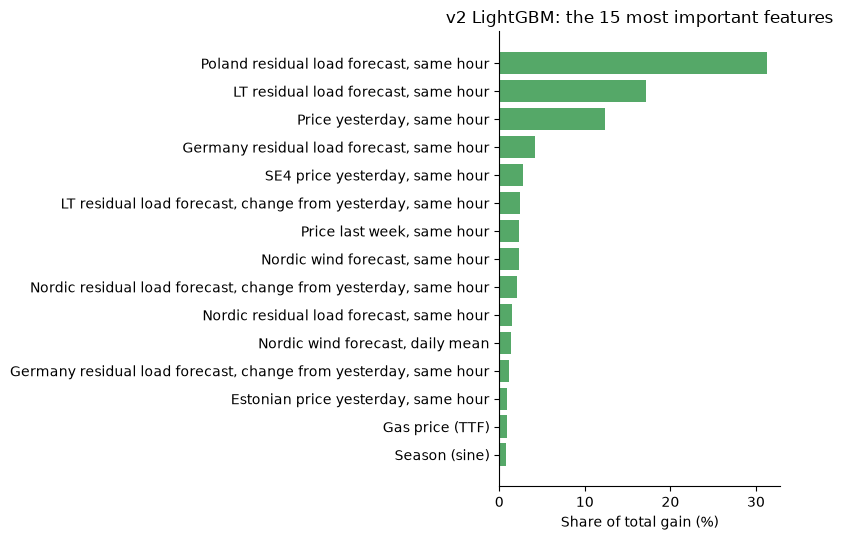

In [23]:
all_days = pd.date_range(TEST[0], last_day, freq="D")
monthly = pd.DataFrame({name: mae_by(pred, all_days, "month") for name, pred in
                        {"naive": forecasts["Naive"], "v1 ensemble": v1["Ensemble"], "v2 main": v2[V2_MAIN]}.items()})
monthly["v1 better than naive, %"] = 100 * (1 - monthly["v1 ensemble"] / monthly["naive"])
monthly["v2 better than naive, %"] = 100 * (1 - monthly["v2 main"] / monthly["naive"])
display(monthly.round(1))

fig, ax = plt.subplots(figsize=(8, 5.5))
model_imp, _ = fit_lgb("v2", TEST[1], V2_PARAMS, V2_TREES[HALF_LIVES[-1]], HALF_LIVES[-1])
imp = pd.Series(model_imp.booster_.feature_importance("gain"), index=feats2).sort_values(ascending=False)
top2 = (100 * imp / imp.sum()).head(15)
ax.barh([readable(n) for n in top2.index[::-1]], top2.to_numpy()[::-1], color="#55a868")
ax.set_xlabel("Share of total gain (%)")
ax.set_title("v2 LightGBM: the 15 most important features")
fig.tight_layout()
fig.savefig(FIG / "q3_v2_feature_importance.png", dpi=150)
plt.show()

## 10. Forecasting the uncertainty: 80% prediction intervals

A point forecast says nothing about how likely a spike is. **Quantile regression averaging** (QRA; Nowotarski &
Weron, 2015) turns the two v2 forecasts into quantiles: for every day and hour, the price is regressed on the Lasso
and LightGBM forecasts of the previous 56 days, separately for the 10th, 50th and 90th percentile. The benchmark adds
the 10th and 90th percentiles of the last 56 days' ensemble errors (same hour) to the ensemble forecast.

A good 80% interval contains the actual price about 80% of the time and is as narrow as possible; the **pinball
loss** scores both at once (lower is better). Both methods use only forecasts and prices known before the auction.

coverage of the 80% interval, %  \
test (Jan–Aug 2026, indicative)   QRA                                    73.78   
                                  past errors                            75.77   
fresh (01 Sep–26 Sep 2026, clean) QRA                                    67.58   
                                  past errors                            64.53   

                                               mean width, €/MWh  pinball loss  
test (Jan–Aug 2026, indicative)   QRA                      66.11          7.64  
                                  past errors              67.00          7.76  
fresh (01 Sep–26 Sep 2026, clean) QRA                      83.11         10.56  
                                  past errors              79.31         10.68

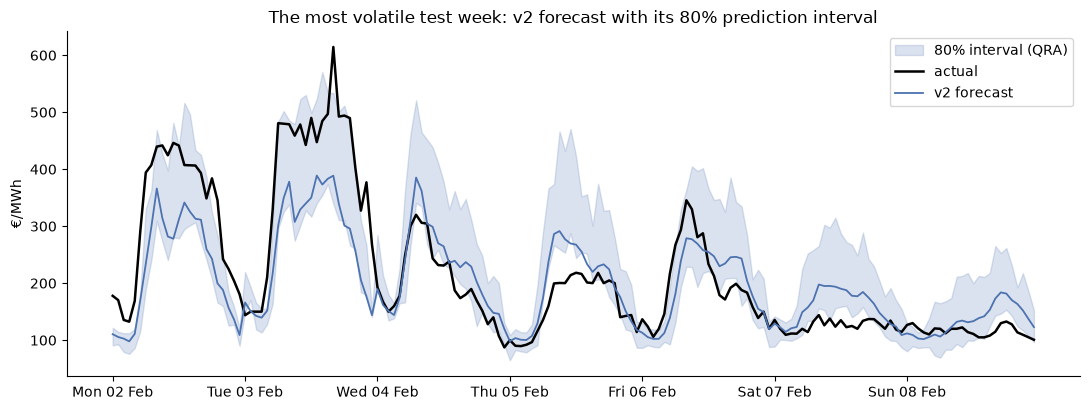

In [24]:
from statsmodels.regression.quantile_regression import QuantReg

QUANTILES = [0.1, 0.5, 0.9]
interval_days = pd.date_range(TEST[0], last_day, freq="D")
L_np, G_np = v2["Lasso"].reindex(DAYS).to_numpy(), v2["LightGBM"].reindex(DAYS).to_numpy()
E_np = v2[V2_MAIN].reindex(DAYS).to_numpy()
R_np = REAL.to_numpy()


def interval_forecasts(window=56):
    # QRA and the past-error benchmark for every day in interval_days, from the previous `window` days only.
    qra = {q: np.full((len(interval_days), 24), np.nan) for q in QUANTILES}
    bench = {q: np.full((len(interval_days), 24), np.nan) for q in QUANTILES}
    for i, day in enumerate(interval_days):
        t = DAY_POS[day]
        past = slice(t - window, t)
        for h in range(24):
            y, l, g, e = P_NP[past, h], L_np[past, h], G_np[past, h], E_np[past, h]
            ok = np.isfinite(y) & np.isfinite(l) & np.isfinite(g) & R_np[past, h]
            if ok.sum() < 30 or not np.isfinite([L_np[t, h], G_np[t, h]]).all():
                continue
            X = np.column_stack([np.ones(ok.sum()), l[ok], g[ok]])
            x_new = np.array([1.0, L_np[t, h], G_np[t, h]])
            values = sorted(float(QuantReg(y[ok], X).fit(q=q, max_iter=5000).params @ x_new) for q in QUANTILES)
            past_errors = y[ok] - e[ok]
            for q, v in zip(QUANTILES, values):
                qra[q][i, h] = v
                bench[q][i, h] = E_np[t, h] + (np.quantile(past_errors, q) if q != 0.5 else 0.0)
    to_frame = lambda arr: pd.DataFrame(arr, index=interval_days, columns=range(24))
    return ({q: to_frame(a) for q, a in qra.items()}, {q: to_frame(a) for q, a in bench.items()})


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    QRA, BENCH = cached("intervals", interval_forecasts)


def interval_scores(quantiles, days):
    real = REAL.reindex(days)
    y = P.reindex(days).where(real)
    low, high = quantiles[0.1].reindex(days), quantiles[0.9].reindex(days)
    pinball = np.nanmean([np.nanmean(np.maximum(q * (y - quantiles[q].reindex(days)),
                                                (q - 1) * (y - quantiles[q].reindex(days))).to_numpy())
                          for q in QUANTILES])
    inside = ((y >= low) & (y <= high)).where(y.notna() & low.notna())
    return {"coverage of the 80% interval, %": 100 * np.nanmean(inside.to_numpy(dtype=float)),
            "mean width, €/MWh": np.nanmean((high - low).where(real).to_numpy()), "pinball loss": pinball}


interval_table = pd.DataFrame({(label, method): interval_scores(qs, days)
                               for label, days in periods.items()
                               for method, qs in [("QRA", QRA), ("past errors", BENCH)]}).T
display(interval_table.round(2))

fig, ax = plt.subplots(figsize=(11, 4.2))
real_week = REAL.reindex(week_days)
flat_week = lambda table: table.reindex(week_days).where(real_week).to_numpy().ravel()
x = np.arange(24 * len(week_days))
ax.fill_between(x, flat_week(QRA[0.1]), flat_week(QRA[0.9]), color="#4c72b0", alpha=0.2, label="80% interval (QRA)")
ax.plot(x, flat_week(P), color="black", lw=1.8, label="actual")
ax.plot(x, flat_week(v2[V2_MAIN]), color="#4c72b0", lw=1.3, label="v2 forecast")
ax.set_xticks(range(0, 24 * len(week_days), 24), [d.strftime("%a %d %b") for d in week_days])
ax.set_ylabel("€/MWh")
ax.set_title("The most volatile test week: v2 forecast with its 80% prediction interval")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q3_v2_interval_week.png", dpi=150)
plt.show()

## 11. How close is the forecast in practice?

Everyday measures of accuracy: how often the forecast lands within ±10, ±20 and ±50 €/MWh of the actual price, how
well it forecasts the daily average and whether that average goes up or down against yesterday, and whether it finds
the day's most expensive and cheapest hour (within one hour). Like everything from section 9 on, this describes the
fixed v2 model; nothing is chosen here.

In [26]:
# How often is the v2 forecast close to the actual price?
rows = {}
for label, days in periods.items():
    real = REAL.reindex(days)
    pred, actual = v2[V2_MAIN].reindex(days).where(real), P.reindex(days).where(real)
    abs_err = (pred - actual).abs().to_numpy().ravel()
    abs_err = abs_err[np.isfinite(abs_err)]
    daily_pred, daily_actual = pred.mean(axis=1), actual.mean(axis=1)
    yesterday = P.shift(1).reindex(days).mean(axis=1)                  # yesterday's actual daily average
    right_direction = np.sign(daily_pred - yesterday) == np.sign(daily_actual - yesterday)
    rows[label] = {
        "hours within ±10 €/MWh, %": 100 * (abs_err <= 10).mean(),
        "hours within ±20 €/MWh, %": 100 * (abs_err <= 20).mean(),
        "hours within ±50 €/MWh, %": 100 * (abs_err <= 50).mean(),
        "median hourly error, €/MWh": np.median(abs_err),
        "daily average: mean absolute error, €/MWh": (daily_pred - daily_actual).abs().mean(),
        "daily average up/down vs yesterday right, %": 100 * right_direction.mean(),
        "most expensive hour right (±1 h), %": 100 * ((pred.idxmax(axis=1) - actual.idxmax(axis=1)).abs() <= 1).mean(),
        "cheapest hour right (±1 h), %": 100 * ((pred.idxmin(axis=1) - actual.idxmin(axis=1)).abs() <= 1).mean(),
    }
pd.DataFrame(rows).round(1)

,"test (Jan–Aug 2026, indicative)","fresh (01 Sep–26 Sep 2026, clean)"
"hours within ±10 €/MWh, %",32.9,20.9
"hours within ±20 €/MWh, %",58.4,42.2
"hours within ±50 €/MWh, %",90.3,75.3
"median hourly error, €/MWh",16.4,25.1
"daily average: mean absolute error, €/MWh",15.1,25.1
"daily average up/down vs yesterday right, %",88.5,88.5
"most expensive hour right (±1 h), %",73.7,50.0
"cheapest hour right (±1 h), %",50.6,42.3


## 12. What the forecast is worth: a battery test

A price forecast is worth what it earns. Every day, a battery of 1 MW and 2 MWh is scheduled with each model's
forecast for the next day: it charges in the hours the forecast says are cheapest and discharges in the dearest,
starting and ending the day empty, with at most one full cycle a day and a round-trip efficiency of 88%. The plan is
then settled at the actual day-ahead prices. The same plan made with the actual prices (perfect foresight) is the
upper limit.

Simplifications: the battery takes prices as given, there are no grid fees or degradation costs, and it cannot
correct its position intraday. The euro amounts are therefore only indicative; **the share of the perfect-foresight
value is the robust number.**

In [29]:
from scipy.optimize import linprog

POWER_MW, ENERGY_MWH, ROUND_TRIP = 1.0, 2.0, 0.88
ETA = np.sqrt(ROUND_TRIP)  # the same loss when charging and when discharging


def battery_plan(prices, available):
    # The most profitable plan for one day at the given prices: start and end the day empty, at most one full
    # cycle, charging plus discharging never above the power rating. Returns MW sold per hour (negative = buying).
    n = len(prices)
    p = np.where(available, np.nan_to_num(prices), 0.0)
    cap = np.where(available, POWER_MW, 0.0)
    cost = np.concatenate([p, -p, np.zeros(n)])        # variables: charge c, discharge d, state of charge s
    A_eq, b_eq = np.zeros((n + 1, 3 * n)), np.zeros(n + 1)
    for h in range(n):
        A_eq[h, 2 * n + h] = 1.0                        # s_h
        if h > 0:
            A_eq[h, 2 * n + h - 1] = -1.0               # - s_(h-1)
        A_eq[h, h], A_eq[h, n + h] = -ETA, 1.0 / ETA    # - eta * c_h + d_h / eta
    A_eq[n, 3 * n - 1] = 1.0                            # empty at the end of the day
    A_ub = np.zeros((n + 1, 3 * n))
    A_ub[0, n:2 * n] = 1.0 / ETA                        # at most one full cycle of stored energy a day
    for h in range(n):
        A_ub[h + 1, h] = A_ub[h + 1, n + h] = 1.0       # charge + discharge <= power rating
    b_ub = np.concatenate([[ENERGY_MWH], cap])
    bounds = [(0, c) for c in cap] * 2 + [(0, ENERGY_MWH)] * n
    res = linprog(cost, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    return res.x[n:2 * n] - res.x[:n]


strategies = {"perfect foresight": P, "naive": forecasts["Naive"], "v1 ensemble (pre-registered)": v1["Ensemble"],
              "v2 main": v2[V2_MAIN]}
battery_days = pd.date_range(TEST[0], last_day, freq="D")
profit = pd.DataFrame(index=battery_days, columns=list(strategies), dtype=float)
for day in battery_days:
    actual = P.loc[day].to_numpy()
    real = REAL.loc[day].to_numpy() & np.isfinite(actual)
    for name, table in strategies.items():
        forecast = table.loc[day].to_numpy()
        ok = real & np.isfinite(forecast)
        profit.loc[day, name] = float(np.sum(np.where(ok, actual, 0.0) * battery_plan(forecast, ok)))

rows = {}
for label, days in periods.items():
    total = profit.reindex(days).sum()
    for name in strategies:
        rows[(label, name)] = {"profit, € per MW": total[name],
                               "share of perfect foresight, %": 100 * total[name] / total["perfect foresight"],
                               "per MW and year, €": total[name] * 365 / len(days)}
battery = pd.DataFrame(rows).T
display(battery.round(1))

profit, € per MW  \
test (Jan–Aug 2026, indicative)   perfect foresight                      56113.5   
                                  naive                                  43554.9   
                                  v1 ensemble (pre-registered)           49897.4   
                                  v2 main                                50044.9   
fresh (01 Sep–26 Sep 2026, clean) perfect foresight                       6038.3   
                                  naive                                   3643.2   
                                  v1 ensemble (pre-registered)            5158.9   
                                  v2 main                                 5188.7   

                                                                share of perfect foresight, %  \
test (Jan–Aug 2026, indicative)   perfect foresight                                     100.0   
                                  naive                                                  77.6   
                                  v1 ensemble (pre-registered)                           88.9   
                                  v2 main                                                89.2   
fresh (01 Sep–26 Sep 2026, clean) perfect foresight                                     100.0   
                                  naive                                                  60.3   
                                  v1 ensemble (pre-registered)                           85.4   
                                  v2 main                                                85.9   

                                                                per MW and year, €  
test (Jan–Aug 2026, indicative)   perfect foresight                        84285.8  
                                  naive                                    65422.0  
                                  v1 ensemble (pre-registered)             74948.7  
                                  v2 main                                  75170.3  
fresh (01 Sep–26 Sep 2026, clean) perfect foresight                        84767.9  
                                  naive                                    51144.9  
                                  v1 ensemble (pre-registered)             72423.6  
                                  v2 main                                  72840.7

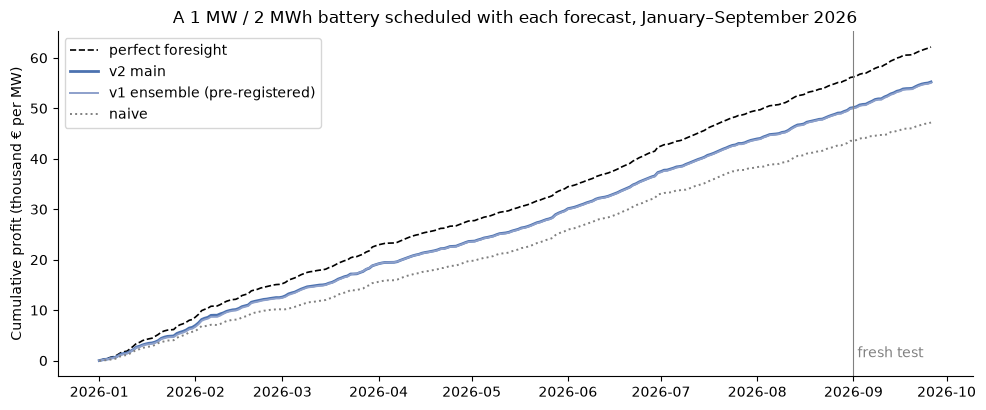

In [30]:
fig, ax = plt.subplots(figsize=(10, 4.2))
cumulative = profit.cumsum() / 1000
for name, style in [("perfect foresight", dict(color="black", ls="--", lw=1.2)),
                    ("v2 main", dict(color="#4c72b0", lw=2)),
                    ("v1 ensemble (pre-registered)", dict(color="#8da0cb", lw=1.4)),
                    ("naive", dict(color="grey", ls=":", lw=1.4))]:
    ax.plot(cumulative.index, cumulative[name], label=name, **style)
if HAS_FRESH:
    ax.axvline(FRESH[0], color="grey", lw=0.8)
    ax.text(FRESH[0], 0, " fresh test", color="grey", va="bottom")
ax.set_ylabel("Cumulative profit (thousand € per MW)")
ax.set_title("A 1 MW / 2 MWh battery scheduled with each forecast, January–September 2026")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "q3_battery_value.png", dpi=150)
plt.show()

## 13. Summary of the improvements

In [31]:
rows = [["Validation choice, Lasso", LASSO_CHOICE], ["Validation choice, LightGBM", LGB_CHOICE]]
for label, days in periods.items():
    table = compare(days)
    t = tests.loc[(label, "v2 main vs v1 ensemble")]
    rows.append([f"{label}: MAE v2 main vs v1 ensemble",
                 f"{table.loc['v2 ensemble, hour weights (v2 main)', 'MAE, €/MWh']:.2f} vs "
                 f"{table.loc['v1 ensemble (pre-registered)', 'MAE, €/MWh']:.2f} €/MWh "
                 f"({change(table.loc['v2 ensemble, hour weights (v2 main)', 'MAE, €/MWh'], table.loc['v1 ensemble (pre-registered)', 'MAE, €/MWh'])}; "
                 f"DM {fmt_p(t['DM p'])}, GW {fmt_p(t['GW p'])})"])
    rows.append([f"{label}: MAE relative to the weekly naive, v1 / v2",
                 f"{table.loc['v1 ensemble (pre-registered)', 'MAE relative to weekly naive']:.2f} / "
                 f"{table.loc['v2 ensemble, hour weights (v2 main)', 'MAE relative to weekly naive']:.2f}"])
    qra = interval_table.loc[(label, "QRA")]
    rows.append([f"{label}: 80% interval (QRA)",
                 f"covers {qra['coverage of the 80% interval, %']:.0f}% of hours, mean width {qra['mean width, €/MWh']:.0f} €/MWh"])
for label in periods:
    share = battery.loc[label, "share of perfect foresight, %"]
    rows.append([f"{label}: battery value captured (share of perfect foresight), v1 / v2",
                 f"{share['v1 ensemble (pre-registered)']:.0f}% / {share['v2 main']:.0f}%"])
v2_summary = pd.DataFrame(rows, columns=["finding", "estimate"])
v2_summary.to_csv(FIG / "q3_v2_summary.csv", index=False)
v2_summary

,finding,estimate
0,"Validation choice, Lasso","v2 inputs, windows 56/84/364/728"
1,"Validation choice, LightGBM","v2 inputs, averaged half-lives"
2,"test (Jan–Aug 2026, indicative): MAE v2 main v...","22.88 vs 24.57 €/MWh (7% lower; DM p < 0.001, ..."
3,"test (Jan–Aug 2026, indicative): MAE relative ...",0.49 / 0.45
4,"test (Jan–Aug 2026, indicative): 80% interval ...","covers 74% of hours, mean width 66 €/MWh"
5,"fresh (01 Sep–26 Sep 2026, clean): MAE v2 main...","32.83 vs 34.19 €/MWh (4% lower; DM p = 0.041, ..."
6,"fresh (01 Sep–26 Sep 2026, clean): MAE relativ...",0.39 / 0.38
7,"fresh (01 Sep–26 Sep 2026, clean): 80% interva...","covers 68% of hours, mean width 83 €/MWh"
8,"test (Jan–Aug 2026, indicative): battery value...",89% / 89%
9,"fresh (01 Sep–26 Sep 2026, clean): battery val...",85% / 86%


## 14. Interpretation of the improvements — write this in your own words

1. Which v2 versions did validation choose, and what do the validation scores say about the new inputs and the short windows?
2. Is v2 better than the pre-registered model on the fresh period (the clean test)? How large and how certain is the difference, given how short the period is? What does the test period (indicative) add?
3. How do the models compare with the literature once the MAE is measured against the weekly naive?
4. Which new inputs does v2's LightGBM use most (cross-border capacities, yesterday's forecasts, the carbon proxy, the corrected load)? How much did the rooftop-solar correction reduce the load forecast error?
5. Are the 80% intervals well calibrated (coverage close to 80%)? Which method is better? What does the interval show in the volatile February week, and how could a trader use it?
6. What would you try next, and why must it be tested on data after September 2026?
7. In everyday terms: how often is the forecast within ±20 €/MWh, how often does it get the direction of tomorrow's average right, and how often does it find the most expensive and the cheapest hour? Why is the cheapest hour harder, and how much does missing it cost?
8. How much of the perfect-foresight battery value do the forecasts capture? What is v2's improvement over v1 worth per MW and year, and what could that mean for a storage portfolio such as Ignitis'?